<a href="https://colab.research.google.com/github/awinarko-hue/Latihan/blob/main/RF_DT/RF_VS_XGBOOST_Opt_Mockup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=============================================================================
# Prediksi Kualitas Sinyal 4G LTE - Gunungkidul, DIY

Model: XGBoost + Random Forest (Multi-Output Regression)
=============================================================================
Penelitian: "Prediksi dan Pemetaan Spasial Kualitas Sinyal 4G LTE
            Menggunakan Machine Learning Berbasis Data Drive Test"
Dataset   : 4G_GK.csv (905,942 record, 3 Operator: IOH, TSEL, XLS)
Target    : RSRP, RSRQ, SINR
=============================================================================

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


Impor library standar analisis data dan machine learning seperti numpy, pandas, matplotlib, seaborn, scikit-learn, joblib, dan xgboost.

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import joblib
import xgboost as xgb

In [ ]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

Bagian konfigurasi menetapkan path data, folder output, nama target, ukuran sampel, dan parameter split train/validation/test. Ada juga pengaturan visual seperti DPI plot dan font agar hasil grafik rapi.

In [ ]:
file1 = "/content/drive/MyDrive/Dataset/Gunung Kidul/GK/4G_GK_1.csv"
file2 = "/content/drive/MyDrive/Dataset/Gunung Kidul/GK/4G_GK_2.csv"
file3 = "/content/drive/MyDrive/Dataset/Gunung Kidul/GK/4G_GK_3.csv"
file4 = "/content/drive/MyDrive/Dataset/Gunung Kidul/GK/4G_GK_4.csv"
file5 = "/content/drive/MyDrive/Dataset/Gunung Kidul/GK/4G_GK_5.csv"
file6 = "/content/drive/MyDrive/Dataset/Gunung Kidul/GK/4G_GK_6.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)
df4 = pd.read_csv(file4)
df5 = pd.read_csv(file5)
df6 = pd.read_csv(file6)

df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

OUTPUT_DIR  = Path("/content/drive/MyDrive/Dataset/Gunung Kidul/GK/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGETS     = ["RSRP", "RSRQ", "SINR"]
SAMPLE_SIZE = 200_000
RANDOM_SEED = 42
TEST_SIZE   = 0.15
VAL_SIZE    = 0.15

print("=" * 65)
print("  PREDIKSI KUALITAS SINYAL 4G LTE — GUNUNGKIDUL")
print("  Model: XGBoost + Random Forest (Multi-Output Regression)")
print("=" * 65)

print("Total record setelah digabung:", len(df))
print("Kolom:", df.columns.tolist())

  PREDIKSI KUALITAS SINYAL 4G LTE — GUNUNGKIDUL
  Model: XGBoost + Random Forest (Multi-Output Regression)
Total record setelah digabung: 905942
Kolom: ['Time', 'Date', 'Collection', 'Session Id', 'RSRP', 'RSRQ', 'SINR', 'PCI LTE', 'DL EARFCN', 'Home Operator', 'Operator', 'MCC', 'MNC', 'Technology', 'Technology Band', 'CGI', 'eNB-Id / Sector Id', 'Cell Id', 'Cell Type', 'File Name', 'Latitude', 'Longitude', 'OperatorShort']


Blok ini membaca file 4GGK.csv ke dalam dfraw.

Setelah itu notebook menampilkan jumlah record dan daftar kolom agar pengguna tahu struktur data mentahnya.

Dari ringkasan PDF, dataset awal berisi 905,942 record dengan kolom seperti waktu, operator, band, RSRP, RSRQ, SINR, latitude, longitude, dan lain-lain.
Karena data sangat besar, notebook mengambil subset dengan stratified sampling.

Maksudnya, sampel diambil sambil menjaga proporsi kombinasi OperatorShort dan Technology Band agar distribusi data tetap representatif.

Kalau kolom stratifikasi tersedia, data dikelompokkan lalu dari tiap grup diambil sebagian baris.

Kalau tidak, notebook jatuh ke sampling biasa menggunakan sample().

In [ ]:
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
print("\n[1/7] Loading dataset...")
df_raw = df
print(f"      Total records : {len(df_raw):,}")
print(f"      Kolom         : {df_raw.columns.tolist()}")

# Stratified sample (jaga proporsi operator & band)
if SAMPLE_SIZE and len(df_raw) > SAMPLE_SIZE:
    # pandas 3.x drops groupby-keys saat apply; pakai simple stratified sampling
    strat_cols = [c for c in ['OperatorShort', 'Technology Band']
                  if c in df_raw.columns]
    if strat_cols:
        grp_sizes = df_raw.groupby(strat_cols).size()
        sampled_indices = []
        for grp_key, grp_df in df_raw.groupby(strat_cols):
            n_take = max(1, int(SAMPLE_SIZE * len(grp_df) / len(df_raw)))
            sampled_indices.append(
                grp_df.sample(min(n_take, len(grp_df)),
                              random_state=RANDOM_SEED)
            )
        df_raw = pd.concat(sampled_indices).reset_index(drop=True)
    df_raw = df_raw.sample(min(SAMPLE_SIZE, len(df_raw)),
                            random_state=RANDOM_SEED).reset_index(drop=True)
    print(f"      Sample dipakai : {len(df_raw):,} record")


[1/7] Loading dataset...
      Total records : 905,942
      Kolom         : ['Time', 'Date', 'Collection', 'Session Id', 'RSRP', 'RSRQ', 'SINR', 'PCI LTE', 'DL EARFCN', 'Home Operator', 'Operator', 'MCC', 'MNC', 'Technology', 'Technology Band', 'CGI', 'eNB-Id / Sector Id', 'Cell Id', 'Cell Type', 'File Name', 'Latitude', 'Longitude', 'OperatorShort']
      Sample dipakai : 199,994 record


Blok preprocessing dimulai dengan menyalin dfraw ke df supaya data mentah tidak rusak.

Lalu notebook memfilter hanya data LTE karena fokusnya memang kualitas sinyal 4G LTE.

Setelah itu, baris yang nilai RSRP dan RSRQ-nya di luar rentang fisik yang masuk akal dibuang.

Langkah ini penting supaya model belajar dari data yang realistis, bukan noise atau outlier ekstrem.

Pada bagian ini, nilai kosong SINR diisi dengan median per kombinasi operator dan band.

Kalau masih ada nilai kosong yang belum terisi, dipakai median global sebagai fallback.

Strategi ini masuk akal karena kualitas sinyal sering berbeda antar operator dan band.

Jadi imputasi tidak asal isi satu angka untuk semua data.

In [ ]:
# ─────────────────────────────────────────────
# 2. PREPROCESSING
# ─────────────────────────────────────────────
print("\n[2/7] Preprocessing data...")
df = df_raw.copy()

# 2a. Filter hanya LTE
df = df[df['Technology'] == 'LTE'].reset_index(drop=True)

# 2b. Filter range nilai fisik yang valid
df = df[(df['RSRP'].between(-140, -40)) &
        (df['RSRQ'].between(-20, -3))].reset_index(drop=True)

# 2c. Imputasi SINR null (median per operator per band)
sinr_null_before = df['SINR'].isnull().sum()
grp_cols = [c for c in ['OperatorShort', 'Technology Band'] if c in df.columns]
if grp_cols:
    df['SINR'] = df.groupby(grp_cols)['SINR'] \
                   .transform(lambda x: x.fillna(x.median()))
df['SINR'] = df['SINR'].fillna(df['SINR'].median())   # fallback global
print(f"      SINR null diimputasi: {sinr_null_before:,} baris")

# 2d. Parse fitur waktu
df['DateTime'] = pd.to_datetime(df['Time'], errors='coerce')
df['hour']     = df['DateTime'].dt.hour
df['dayofweek']= df['DateTime'].dt.dayofweek
df['is_peak']  = df['hour'].between(7, 9) | df['hour'].between(17, 21)
df['is_peak']  = df['is_peak'].astype(int)

# 2e. Encoding fitur kategorikal
band_map      = {'LTE E-UTRA 1': 1, 'LTE E-UTRA 3': 3, 'LTE E-UTRA 8': 8}
df['Band']    = df['Technology Band'].map(band_map).fillna(0).astype(int)

cell_map      = {'MCG PCell': 0, 'MCG SCell1': 1, 'MCG SCell2': 2, 'MCG SCell3': 3}
df['CellTypeEnc'] = df['Cell Type'].map(cell_map).fillna(-1).astype(int)

le_op = LabelEncoder()
df['OperatorEnc'] = le_op.fit_transform(df['OperatorShort'].fillna('Unknown'))

# 2f. Fitur turunan
df['lat_norm'] = (df['Latitude']  - df['Latitude'].mean())  / df['Latitude'].std()
df['lon_norm'] = (df['Longitude'] - df['Longitude'].mean()) / df['Longitude'].std()
df['is_carrier_agg'] = (df['CellTypeEnc'] > 0).astype(int)

print(f"      Record setelah cleaning: {len(df):,}")
print(f"      Distribusi Operator:\n{df['OperatorShort'].value_counts().to_string()}")
print(f"      Distribusi Band:\n{df['Technology Band'].value_counts().to_string()}")



[2/7] Preprocessing data...
      SINR null diimputasi: 77,382 baris


/tmp/ipykernel_1981/2727478482.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['Time'], errors='coerce')


      Record setelah cleaning: 198,412
      Distribusi Operator:
OperatorShort
TSEL    86108
XLS     56318
IOH     55986
      Distribusi Band:
Technology Band
LTE E-UTRA 40    63666
LTE E-UTRA 3     63044
LTE E-UTRA 1     58942
LTE E-UTRA 8     10579
LTE E-UTRA 5      2181


Notebook membuat fitur latnorm dan lonnorm dari latitude dan longitude yang sudah distandardisasi terhadap rata-rata dan standar deviasi.

Ini membantu model melihat posisi relatif, bukan hanya angka koordinat mentah.

Ada juga iscarrieragg yang bernilai 1 jika CellTypeEnc == 0, sehingga menangkap status carrier aggregation.

Fitur ini relevan karena kondisi jaringan bisa berbeda saat CA aktif.

Di blok ini notebook mendefinisikan FEATURES dan TARGETS.

Fitur input yang dipakai berjumlah 13 dan mencakup aspek spasial, frekuensi, identitas sel, operator, dan waktu.

Setelah itu dibuat dfmodel = df[FEATURES + TARGETS].dropna().

Artinya semua baris yang masih punya nilai kosong di fitur atau target dibuang agar training bersih.

In [ ]:
# ─────────────────────────────────────────────
# 3. FEATURE SELECTION
# ─────────────────────────────────────────────
print("\n[3/7] Feature engineering...")
FEATURES = [
    'Latitude', 'Longitude',       # spasial
    'lat_norm', 'lon_norm',
    'DL EARFCN',                    # frekuensi downlink
    'Band',                         # band (1/3/8)
    'PCI LTE',                      # Physical Cell ID
    'CellTypeEnc',                  # PCell/SCell
    'OperatorEnc',                  # operator
    'hour', 'dayofweek', 'is_peak', # temporal
    'is_carrier_agg',               # CA status
]

df_model = df[FEATURES + TARGETS]
X = df_model[FEATURES]
y = df_model[TARGETS]

print(f"      Fitur input  : {len(FEATURES)} fitur")
print(f"      Target output: {TARGETS}")
print(f"      Total sampel : {len(df_model):,}")



[3/7] Feature engineering...
      Fitur input  : 13 fitur
      Target output: ['RSRP', 'RSRQ', 'SINR']
      Total sampel : 198,412


Data dibagi menjadi train, validation, dan test.

Pertama dipisah menjadi Xtemp/Xtest dan ytemp/ytest.
Lalu Xtemp dipisah lagi menjadi train dan validation.
Urutan ini membuat notebook punya tiga subset: untuk melatih model, menyetel performa, dan menguji hasil akhir.

Setelah split, fitur numerik distandardisasi dengan StandardScaler.
Scaler hanya di-fit pada data train, lalu diterapkan ke validation dan test.
Ini penting agar tidak terjadi data leakage dari test ke train.
Skema ini juga membuat skala antar fitur lebih seimbang.

In [ ]:
# ─────────────────────────────────────────────
# 4. SPLIT DATA
# ─────────────────────────────────────────────
print("\n[4/7] Split train / val / test...")
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED)

print(f"      Train : {len(X_train):,}  Val: {len(X_val):,}  Test:{len(X_test):,}")

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)



[4/7] Split train / val / test...
      Train : 138,888  Val: 29,762  Test:29,762


5A. Bagian ini melatih model XGBoost satu per satu untuk tiap target.
Untuk tiap target, dibuat XGBRegressor dengan parameter seperti n_estimators=300, learning_rate=0.05, max_depth=8, subsample=0.8, dan colsample_bytree=0.8.
Model dilatih memakai data train dan divalidasi dengan data validation.

5B. Selanjutnya Di sini notebook memakai MultiOutputRegressor(RandomForestRegressor(...)).
Artinya satu wrapper dipakai untuk memprediksi tiga target sekaligus.
Parameter seperti n_estimators=150, max_depth=20, dan min_samples_leaf=5 mengatur kompleksitas pohon.
n_jobs=-1 berarti proses training memakai seluruh core CPU yang tersedia.



In [ ]:
import xgboost as xgb

print("[5/7] Training models...")

# ── 5A. XGBoost (per target) ──────────────────
print("  ▸ Training XGBoost...")
xgb_models = {}
xgb_preds  = {}
for target in TARGETS:
    print(f"    → XGBoost untuk target: {target}")
    model = xgb.XGBRegressor(
        n_estimators     = 300,
        learning_rate    = 0.05,
        max_depth        = 8,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        tree_method      = 'hist',
        eval_metric      = 'rmse',
        early_stopping_rounds = 20,
        random_state     = RANDOM_SEED,
        verbosity        = 0,
    )
    model.fit(
        X_train_s, y_train[target],
        eval_set=[(X_train_s, y_train[target]), (X_val_s, y_val[target])], # Modified: added training set to eval_set
        verbose=False
    )
    xgb_models[target] = model
    xgb_preds[target]  = model.predict(X_test_s)

# ── 5B. Random Forest (multi-output) ─────────
print("  ▸ Training Random Forest...")
rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators = 150,
        max_depth     = 20,
        min_samples_leaf = 5,
        n_jobs       = -1,
        random_state = RANDOM_SEED
    )
)
rf_model.fit(X_train_s, y_train)
rf_preds_arr = rf_model.predict(X_test_s)
rf_preds = {t: rf_preds_arr[:, i] for i, t in enumerate(TARGETS)}

print("  ✓ Training selesai.")

[5/7] Training models...
  ▸ Training XGBoost...
    → XGBoost untuk target: RSRP
    → XGBoost untuk target: RSRQ
    → XGBoost untuk target: SINR
  ▸ Training Random Forest...
  ✓ Training selesai.


Pada bagian evaluasi, notebook membuat fungsi evalmetrics untuk menghitung MAE, RMSE, dan R2.
Fungsi ini dipakai untuk semua kombinasi model dan target.
Hasilnya disimpan ke DataFrame dfresults lalu dicetak.
Dari hasil yang terlihat, Random Forest memberikan performa lebih baik daripada XGBoost untuk ketiga target.


In [ ]:
# ─────────────────────────────────────────────
# 6. EVALUASI
# ─────────────────────────────────────────────
print("\n[6/7] Evaluasi model...")

def eval_metrics(y_true, y_pred, model_name, target):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": model_name, "Target": target,
            "MAE": round(mae,4), "RMSE": round(rmse,4), "R²": round(r2,4)}

results = []
for target in TARGETS:
    results.append(eval_metrics(y_test[target], xgb_preds[target],  "XGBoost",
                                target))
    results.append(eval_metrics(y_test[target], rf_preds[target],
                                "RandomForest",  target))

df_results = pd.DataFrame(results)
print("\n  ┌─────────────────────────────────────────────────────────┐")
print("  │                   HASIL EVALUASI MODEL                  │")
print("  └─────────────────────────────────────────────────────────┘")
print(df_results.to_string(index=False))



[6/7] Evaluasi model...

  ┌─────────────────────────────────────────────────────────┐
  │                   HASIL EVALUASI MODEL                  │
  └─────────────────────────────────────────────────────────┘
       Model Target    MAE   RMSE     R²
     XGBoost   RSRP 2.4861 3.4927 0.8850
RandomForest   RSRP 1.8695 2.6603 0.9333
     XGBoost   RSRQ 1.3008 1.7159 0.7087
RandomForest   RSRQ 1.1422 1.5358 0.7666
     XGBoost   SINR 2.1547 3.1976 0.6632
RandomForest   SINR 1.7725 2.7868 0.7442


### Learning Curves (XGBoost)

Visualisasi *learning curve* menunjukkan performa model pada *training set* dan *validation set* seiring dengan bertambahnya iterasi (boosting rounds). Ini berguna untuk mendeteksi *overfitting* atau *underfitting*.

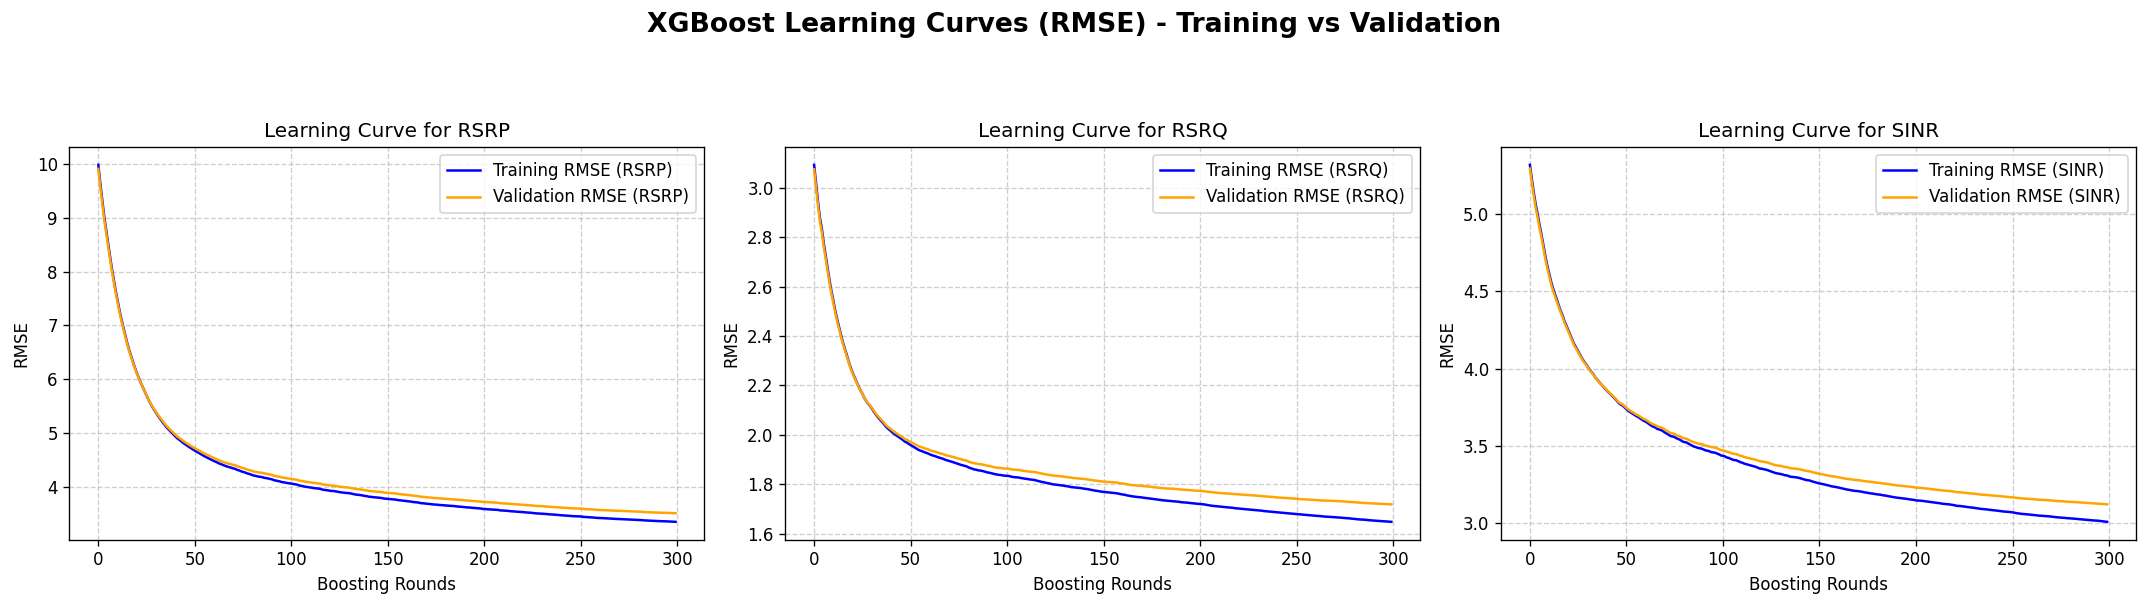

In [ ]:
fig_lc, axes_lc = plt.subplots(1, 3, figsize=(18, 5))
fig_lc.suptitle("XGBoost Learning Curves (RMSE) - Training vs Validation",
              fontsize=16, fontweight='bold', y=1.03)

for i, target in enumerate(TARGETS):
    ax = axes_lc[i]

    model_to_plot = xgb_models.get(target)

    if model_to_plot and hasattr(model_to_plot, 'evals_result_'):
        evals_result = model_to_plot.evals_result()

        # Extract training and validation RMSE from evals_result_
        # 'validation_0' typically corresponds to the first eval_set (training data)
        # 'validation_1' typically corresponds to the second eval_set (validation data)
        train_rmse = evals_result['validation_0']['rmse'] if 'validation_0' in evals_result and 'rmse' in evals_result['validation_0'] else None
        val_rmse   = evals_result['validation_1']['rmse'] if 'validation_1' in evals_result and 'rmse' in evals_result['validation_1'] else None

        if train_rmse and val_rmse:
            ax.plot(train_rmse, label=f'Training RMSE ({target})', color='blue')
            ax.plot(val_rmse, label=f'Validation RMSE ({target})', color='orange')
            ax.set_title(f'Learning Curve for {target}', fontsize=12)
            ax.set_xlabel('Boosting Rounds')
            ax.set_ylabel('RMSE')
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.6)
        elif val_rmse:
            # Fallback if only validation RMSE is available (shouldn't happen after modification)
            ax.plot(val_rmse, label=f'Validation RMSE ({target})', color='orange')
            ax.set_title(f'Learning Curve for {target}', fontsize=12)
            ax.set_xlabel('Boosting Rounds')
            ax.set_ylabel('RMSE')
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.6)
        else:
            ax.set_title(f'No learning curve data for {target}')
            ax.text(0.5, 0.5, 'Learning curve data not available.',
                    horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig_lc.savefig(OUTPUT_DIR / "07_xgboost_learning_curves.png", bbox_inches='tight', dpi=130)
plt.show()

Notebook bisa menghasilkan beberapa grafik penting.
Grafik perbandingan metrik model untuk tiap target.
Scatter plot actual vs predicted untuk XGBoost.
Feature importance untuk tiap target.
Boxplot error absolut per operator.
Peta spasial RSRP aktual dan prediksi.
Semua visual itu disimpan ke folder output.

Di bagian akhir, notebook menyimpan hasil model dan artefak pendukung.
Biasanya yang disimpan adalah model XGBoost, model Random Forest, scaler, encoder, hasil evaluasi CSV, dan gambar visualisasi.
Ini membuat notebook bisa dipakai ulang untuk inferensi atau laporan tanpa training ulang

In [ ]:

# ─────────────────────────────────────────────
# 7. VISUALISASI & SIMPAN
# ─────────────────────────────────────────────
print("\n[7/7] Membuat visualisasi & menyimpan artefak...")

# ── FIG 1: Metrik Perbandingan Model ──────────
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle("Perbandingan Metrik: XGBoost vs Random Forest\n4G LTE Signal Quality Prediction — Gunungkidul",
              fontsize=13, fontweight='bold', y=1.02)
colors = {'XGBoost': '#2563EB', 'RandomForest': '#16A34A'}

for ax, metric in zip(axes1, ['MAE', 'RMSE', 'R²']):
    pivot = df_results.pivot(index='Target', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=[colors[c] for c in pivot.columns],
               edgecolor='white', width=0.65)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
fig1.savefig(OUTPUT_DIR / "01_model_comparison.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 2: Actual vs Predicted (XGBoost) ─────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle("XGBoost: Actual vs Predicted — RSRP, RSRQ, SINR",
              fontsize=13, fontweight='bold')
units = {'RSRP': 'dBm', 'RSRQ': 'dB', 'SINR': 'dB'}

for ax, target in zip(axes2, TARGETS):
    y_true = y_test[target].values
    y_pred = xgb_preds[target]
    idx    = np.random.choice(len(y_true), min(3000, len(y_true)), replace=False)
    ax.scatter(y_true[idx], y_pred[idx], alpha=0.2, s=8,
               color='#2563EB', rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal')
    ax.set_xlabel(f"Actual {target} ({units[target]})")
    ax.set_ylabel(f"Predicted {target} ({units[target]})")
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f"{target}\nR²={r2:.4f}  MAE={mae:.3f} {units[target]}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.tight_layout()
fig2.savefig(OUTPUT_DIR / "02_actual_vs_predicted.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 3: Feature Importance (XGBoost) ──────
fig3, axes3 = plt.subplots(1, 3, figsize=(16, 6))
fig3.suptitle("XGBoost Feature Importance per Target\n(F-Score — Jumlah kemunculan fitur di split)",
              fontsize=13, fontweight='bold')
palette = ['#1D4ED8', '#15803D', '#B45309']

for ax, target, color in zip(axes3, TARGETS, palette):
    importances = xgb_models[target].feature_importances_
    fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(12)
    ax.barh(fi_df['Feature'], fi_df['Importance'], color=color, alpha=0.85)
    ax.set_title(f"Feature Importance: {target}", fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
fig3.savefig(OUTPUT_DIR / "03_feature_importance.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 4: Distribusi Error per Operator ─────
df_test_eval = X_test.copy()
for target in TARGETS:
    df_test_eval[f'{target}_true'] = y_test[target].values
    df_test_eval[f'{target}_pred'] = xgb_preds[target]
    df_test_eval[f'{target}_err']  = np.abs(df_test_eval[f'{target}_true'] - df_test_eval[f'{target}_pred'])

# Decode operator
op_arr = np.array(le_op.classes_)
df_test_eval['Operator'] = op_arr[df_test_eval['OperatorEnc'].values]

fig4, axes4 = plt.subplots(1, 3, figsize=(15, 5))
fig4.suptitle("Distribusi Absolute Error XGBoost per Operator",
              fontsize=13, fontweight='bold')

for ax, target in zip(axes4, TARGETS):
    ops = df_test_eval['Operator'].unique()
    data_plot = [df_test_eval[df_test_eval['Operator']==op][f'{target}_err'].values for op in ops]
    bp = ax.boxplot(data_plot, patch_artist=True, labels=ops,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#3B82F6', '#10B981', '#F59E0B'][:len(ops)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f"Error |{target}|", fontweight='bold')
    ax.set_ylabel(f"MAE ({units[target]})")
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig4.savefig(OUTPUT_DIR / "04_error_per_operator.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 5: Peta Spasial RSRP Prediksi ────────
print("  ▸ Membuat peta spasial prediksi RSRP...")
df_map = X_test.copy()
df_map['RSRP_pred'] = xgb_preds['RSRP']
df_map['RSRP_true'] = y_test['RSRP'].values

fig5, axes5 = plt.subplots(1, 2, figsize=(16, 7))
fig5.suptitle("Peta Spasial RSRP — Wilayah Gunungkidul\n(Kiri: Aktual | Kanan: Prediksi XGBoost)",
              fontsize=13, fontweight='bold')

rsrp_bins  = [-140, -110, -100, -90, -80, -40]
rsrp_labels= ['Very Poor\n(<-110)', 'Poor\n(-110:-100)',
              'Fair\n(-100:-90)', 'Good\n(-90:-80)', 'Excellent\n(>-80)']
rsrp_colors= ['#DC2626','#F97316','#FACC15','#22C55E','#15803D']
cmap_rsrp  = plt.cm.colors.ListedColormap(rsrp_colors)

for ax, col, label in zip(axes5,
                           ['RSRP_true', 'RSRP_pred'],
                           ['RSRP Aktual', 'RSRP Prediksi']):
    sc = ax.scatter(df_map['Longitude'], df_map['Latitude'],
                    c=df_map[col], cmap='RdYlGn',
                    vmin=-120, vmax=-60, s=3, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label='RSRP (dBm)', shrink=0.8)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.2)

plt.tight_layout()
fig5.savefig(OUTPUT_DIR / "05_spatial_map_rsrp.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 6: Analisis per Band ─────────────────
band_decode = {1: 'Band 1 (2100)', 3: 'Band 3 (1800)', 8: 'Band 8 (900)'}
df_test_eval['Band_Name'] = df_test_eval['Band'].map(band_decode)

fig6, axes6 = plt.subplots(1, 3, figsize=(15, 5))
fig6.suptitle("Distribusi Error XGBoost per Technology Band",
              fontsize=13, fontweight='bold')

for ax, target in zip(axes6, TARGETS):
    bands = sorted(df_test_eval['Band'].unique())
    data_band = [df_test_eval[df_test_eval['Band']==b][f'{target}_err'].values for b in bands]
    labels_b  = [band_decode.get(b, str(b)) for b in bands]
    bp = ax.boxplot(data_band, patch_artist=True, labels=labels_b,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#6366F1', '#06B6D4', '#EC4899']):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(f"Error |{target}|", fontweight='bold')
    ax.set_ylabel(f"MAE ({units[target]})")
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig6.savefig(OUTPUT_DIR / "06_error_per_band.png", bbox_inches='tight', dpi=130)
plt.close()

# ── Simpan model & scaler ─────────────────────
for target, model in xgb_models.items():
    joblib.dump(model, OUTPUT_DIR / f"xgb_model_{target}.pkl")
joblib.dump(rf_model, OUTPUT_DIR / "rf_model_multioutput.pkl")
joblib.dump(scaler,   OUTPUT_DIR / "scaler.pkl")
joblib.dump(le_op,    OUTPUT_DIR / "label_encoder_operator.pkl")

# ── Simpan tabel hasil evaluasi ───────────────
df_results.to_csv(OUTPUT_DIR / "hasil_evaluasi.csv", index=False)

# ── Simpan prediksi sample ───────────────────
df_pred_sample = X_test.head(500).copy()
df_pred_sample['Operator'] = op_arr[df_pred_sample['OperatorEnc'].values]
for target in TARGETS:
    df_pred_sample[f'{target}_actual']    = y_test[target].values[:500]
    df_pred_sample[f'{target}_predicted'] = xgb_preds[target][:500]
df_pred_sample.to_csv(OUTPUT_DIR / "sample_predictions.csv", index=False)

# ── Summary  ─────────────────────────────
print("\n" + "=" * 65)
print("  RINGKASAN HASIL AKHIR")
print("=" * 65)
best = df_results[df_results['Model']=='XGBoost']
for _, row in best.iterrows():
    unit = units[row['Target']]
    print(f"  XGBoost | {row['Target']:5s} → MAE={row['MAE']:.3f} {unit}  "
          f"RMSE={row['RMSE']:.3f} {unit}  R²={row['R²']:.4f}")

print("\n  File output tersimpan di:", OUTPUT_DIR)
print("  ✓ Model (.pkl), Visualisasi (.png), CSV hasil evaluasi")
print("=" * 65)


[7/7] Membuat visualisasi & menyimpan artefak...


/tmp/ipykernel_1981/655086397.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True, labels=ops,
/tmp/ipykernel_1981/655086397.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True, labels=ops,
/tmp/ipykernel_1981/655086397.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True, labels=ops,


  ▸ Membuat peta spasial prediksi RSRP...


/tmp/ipykernel_1981/655086397.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_band, patch_artist=True, labels=labels_b,
/tmp/ipykernel_1981/655086397.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_band, patch_artist=True, labels=labels_b,
/tmp/ipykernel_1981/655086397.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_band, patch_artist=True, labels=labels_b,



  RINGKASAN HASIL AKHIR
  XGBoost | RSRP  → MAE=2.486 dBm  RMSE=3.493 dBm  R²=0.8850
  XGBoost | RSRQ  → MAE=1.301 dB  RMSE=1.716 dB  R²=0.7087
  XGBoost | SINR  → MAE=2.155 dB  RMSE=3.198 dB  R²=0.6632

  File output tersimpan di: /content/drive/MyDrive/Dataset/Gunung Kidul/GK/outputs
  ✓ Model (.pkl), Visualisasi (.png), CSV hasil evaluasi


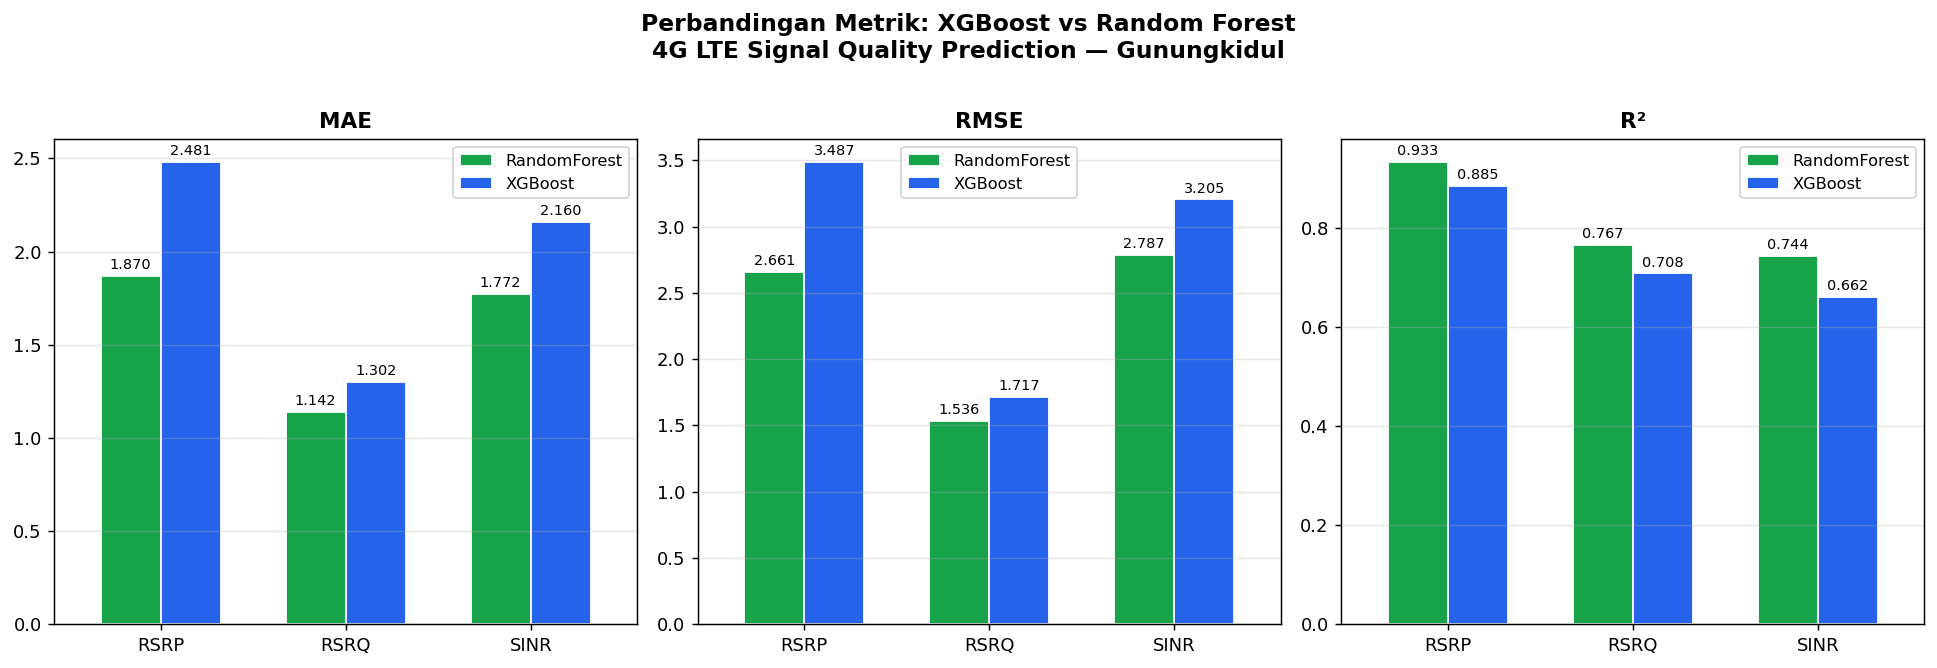

In [ ]:
display(Image(filename=OUTPUT_DIR / "01_model_comparison.png"))

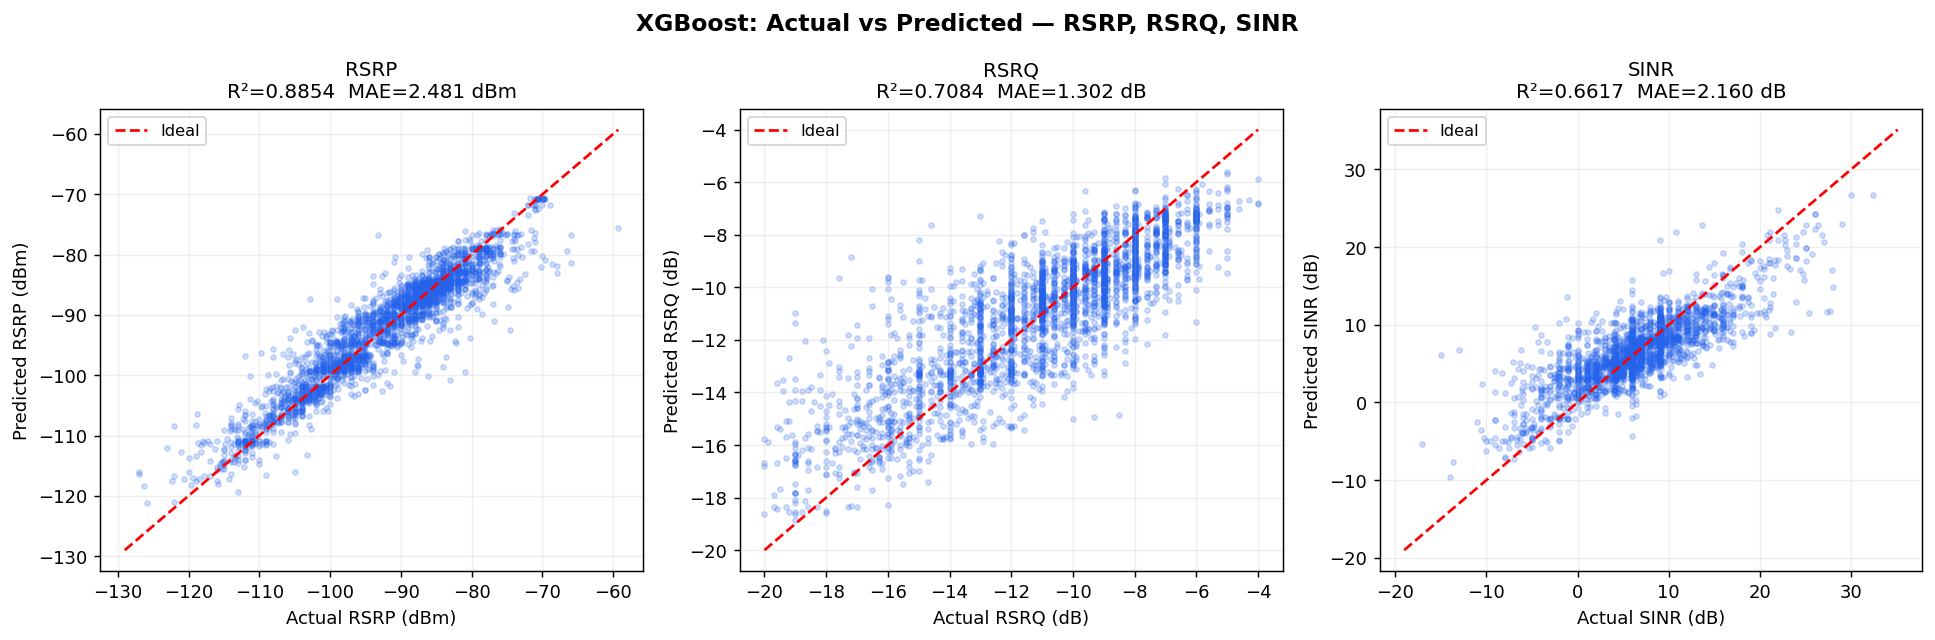

In [ ]:
display(Image(filename=OUTPUT_DIR / "02_actual_vs_predicted.png"))

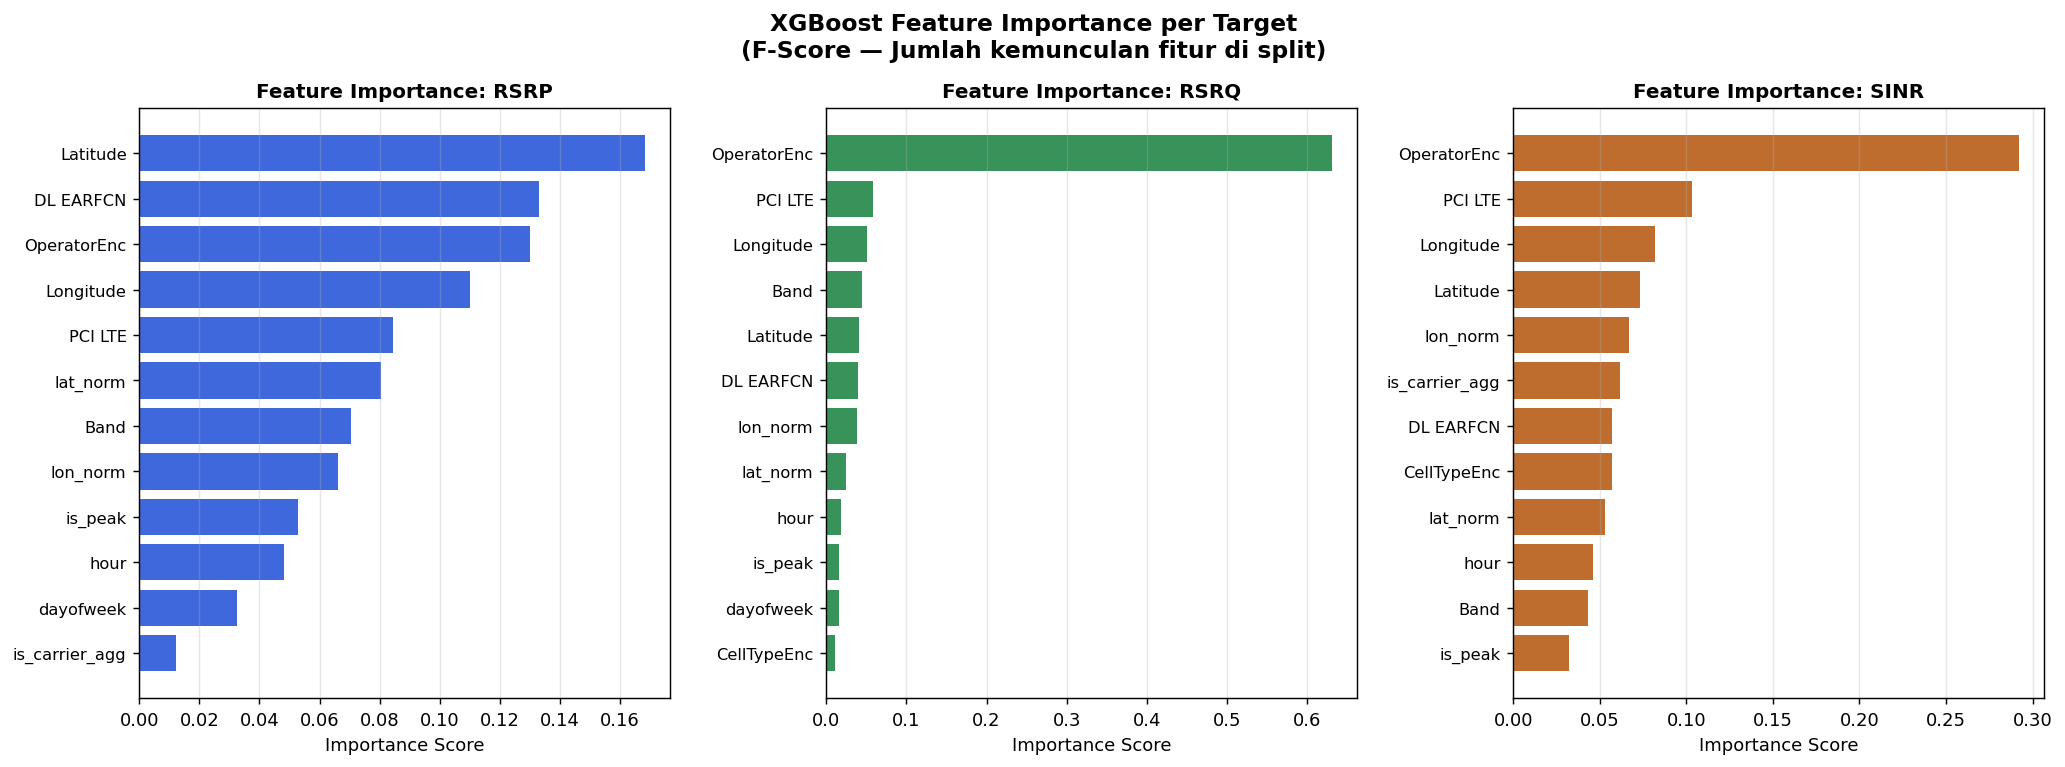

In [ ]:
display(Image(filename=OUTPUT_DIR / "03_feature_importance.png"))

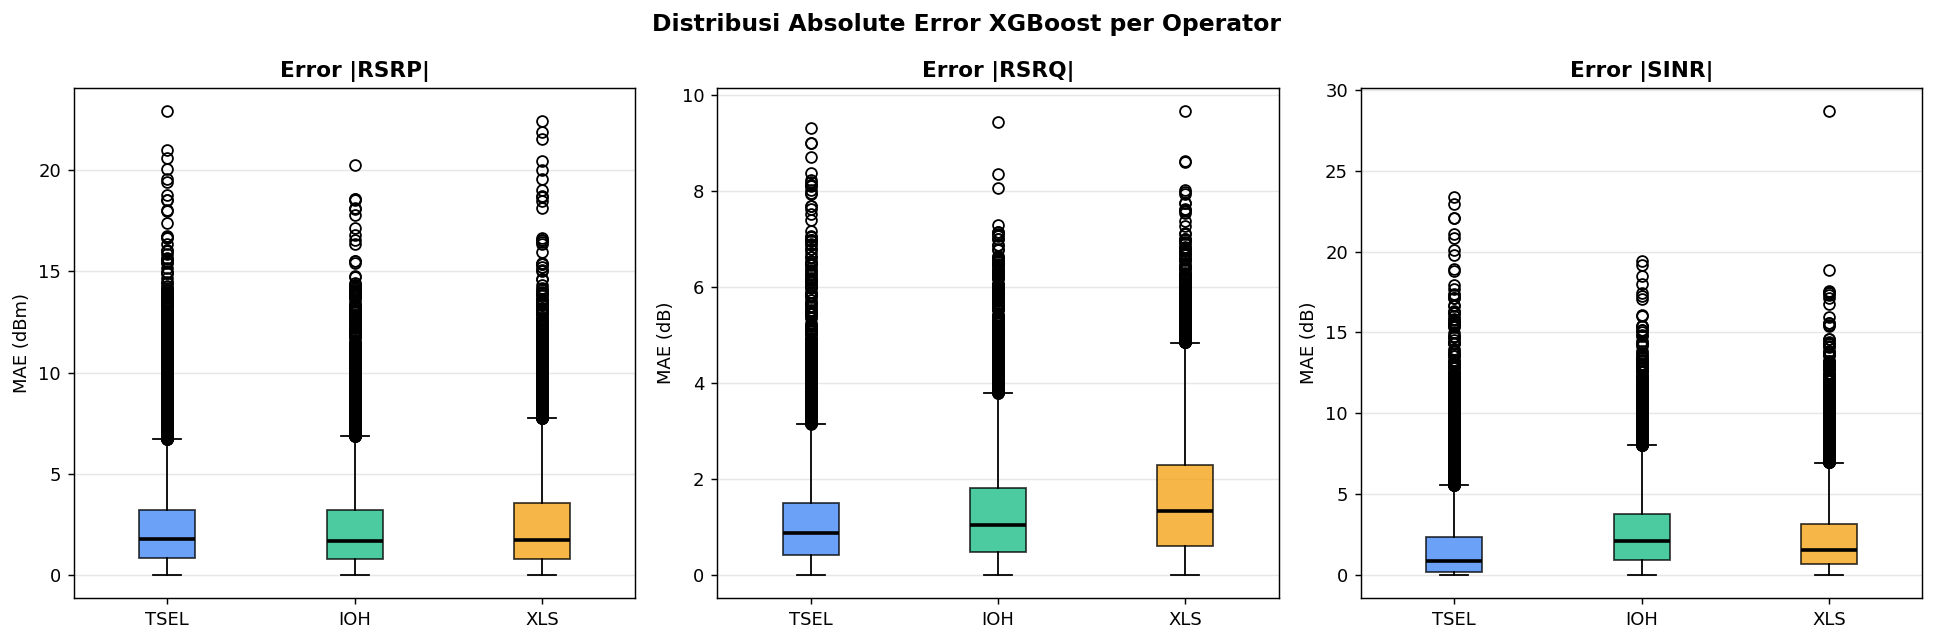

In [ ]:
display(Image(filename=OUTPUT_DIR / "04_error_per_operator.png"))

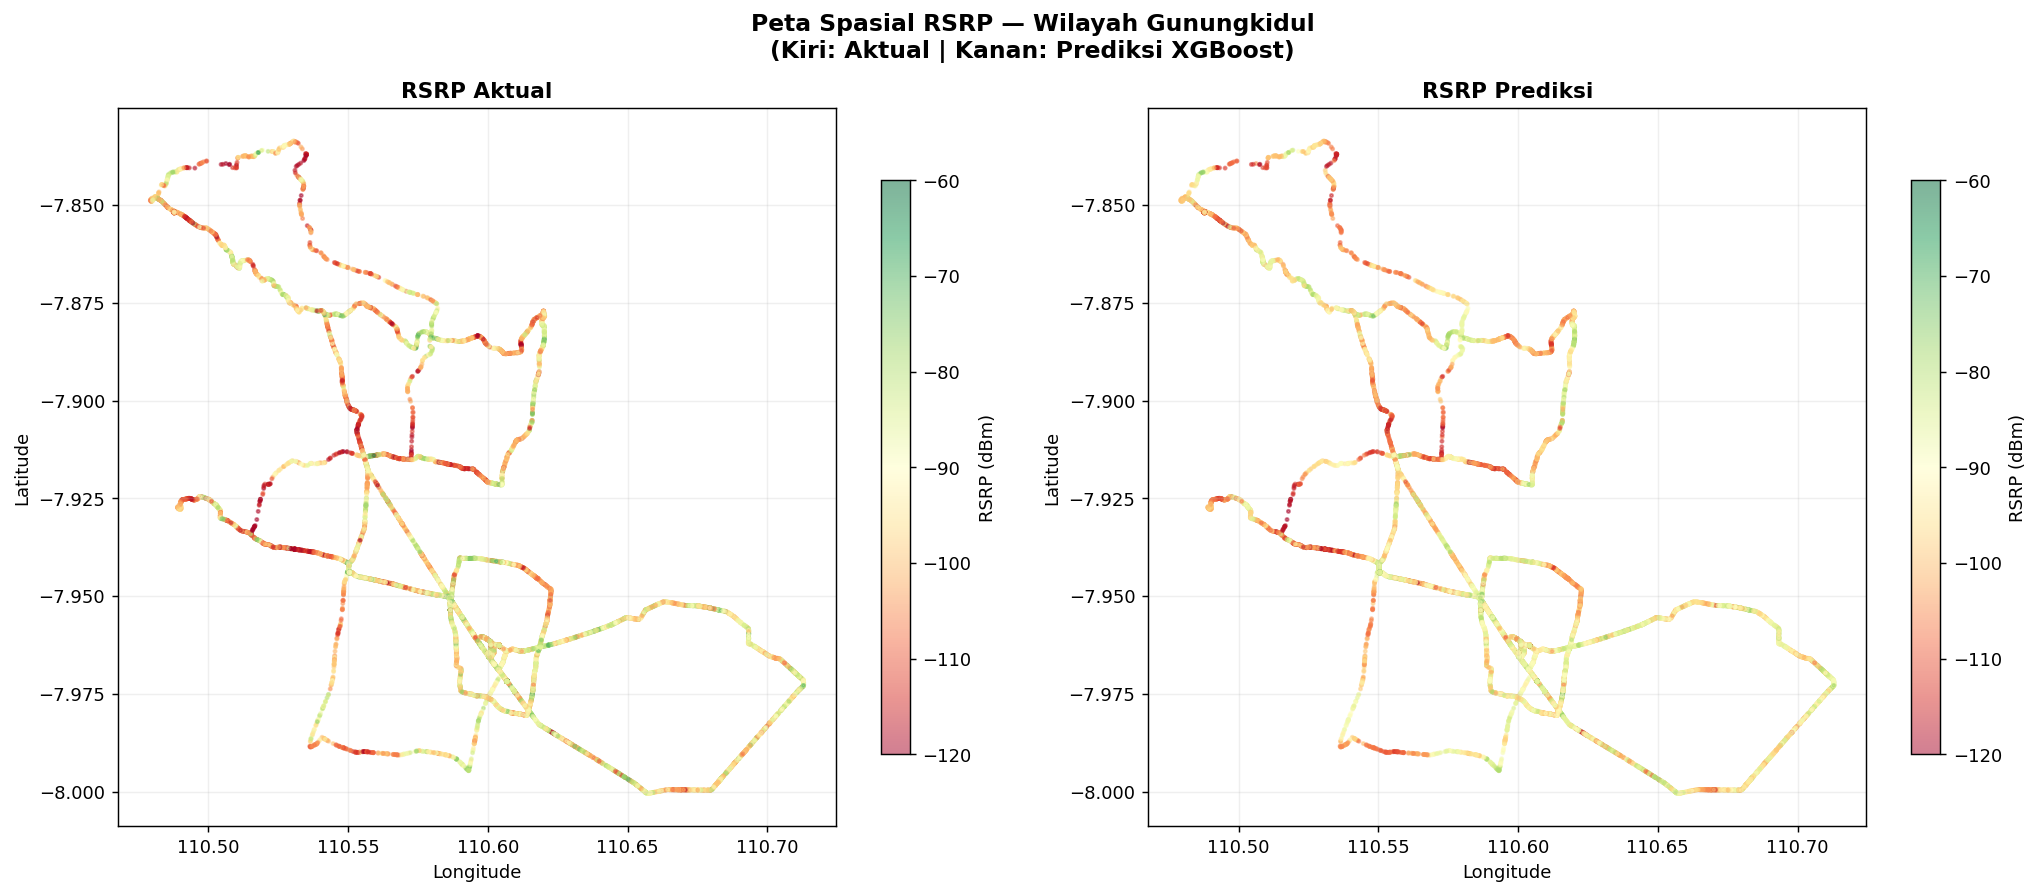

In [ ]:
display(Image(filename=OUTPUT_DIR / "05_spatial_map_rsrp.png"))

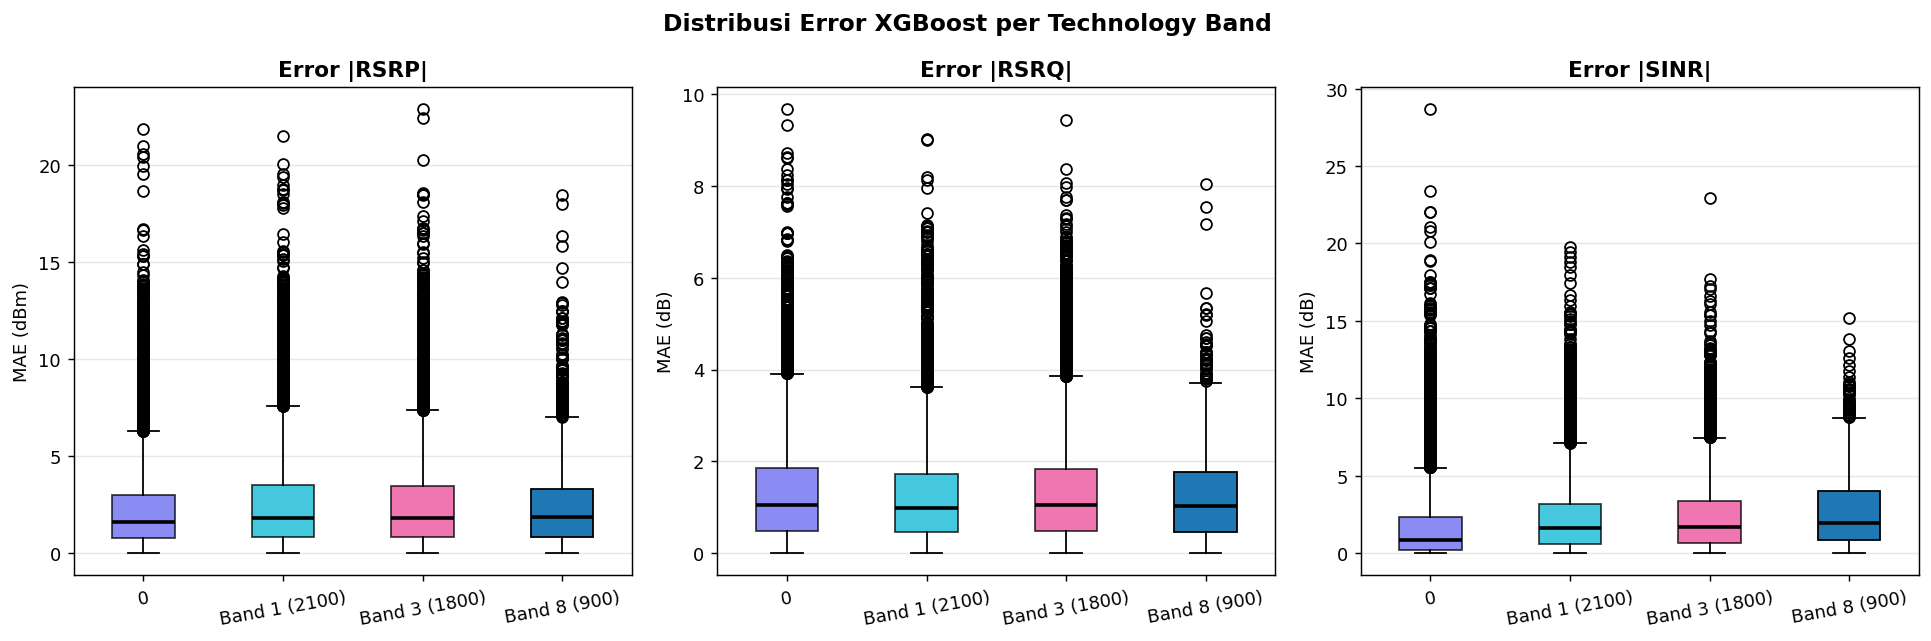

In [ ]:
display(Image(filename=OUTPUT_DIR / "06_error_per_band.png"))

# TUNING atau Optimasi dengan Optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.5 MB/s eta 0:00:00


In [ ]:
# Tambahan dengan optimasi XGBoost Tuning

import optuna
from sklearn.metrics import mean_squared_error
import xgboost as xgb

def objective(trial):
    # Hyperparameter yang akan dicoba
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.0),
        "random_state": 42,
        "tree_method": "hist",
        "eval_metric": "rmse"
    }

    # Model XGBoost untuk target RSRP (bisa diganti RSRQ/SINR)
    model = xgb.XGBRegressor(**params)
    model.fit(X_train_s, y_train["RSRP"],
              eval_set=[(X_val_s, y_val["RSRP"])],
              verbose=False)

    preds = model.predict(X_val_s)
    rmse = np.sqrt(mean_squared_error(y_val["RSRP"], preds)) # Removed squared=False and added np.sqrt
    return rmse

# Jalankan optimasi
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

best_params = study.best_params # Assign best_params here
print("Best params:", best_params)

[I 2026-07-06 13:27:32,688] A new study created in memory with name: no-name-8e768de3-165f-4260-929f-693e1657e7ed
[I 2026-07-06 13:27:51,826] Trial 0 finished with value: 4.763623211872697 and parameters: {'n_estimators': 272, 'learning_rate': 0.05265966323911884, 'max_depth': 5, 'subsample': 0.9020432704027714, 'colsample_bytree': 0.7424601731965851, 'reg_alpha': 0.1373118329420815, 'reg_lambda': 1.753913428462281}. Best is trial 0 with value: 4.763623211872697.
[I 2026-07-06 13:28:23,279] Trial 1 finished with value: 3.073657846909243 and parameters: {'n_estimators': 378, 'learning_rate': 0.0329935254968516, 'max_depth': 11, 'subsample': 0.9304023493494933, 'colsample_bytree': 0.8066530220579127, 'reg_alpha': 0.6733418130837221, 'reg_lambda': 1.475259178514303}. Best is trial 1 with value: 3.073657846909243.
[I 2026-07-06 13:28:42,751] Trial 2 finished with value: 4.14086974632246 and parameters: {'n_estimators': 590, 'learning_rate': 0.11042668737278956, 'max_depth': 4, 'subsample':

Best params: {'n_estimators': 551, 'learning_rate': 0.16136230717137776, 'max_depth': 10, 'subsample': 0.9520773092781815, 'colsample_bytree': 0.8432198764476221, 'reg_alpha': 0.6453795730284417, 'reg_lambda': 0.8447684202962931}


In [ ]:
# Model XGBoost dengan parameter terbaik
best_model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse"
)

# Training ulang dengan data train + validasi
best_model.fit(
    X_train_s, y_train["RSRP"],
    eval_set=[(X_val_s, y_val["RSRP"])],
    verbose=False
)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8432198764476221, device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.16136230717137776,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=551, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
preds = best_model.predict(X_test_s)
mae = mean_absolute_error(y_test["RSRP"], preds)
rmse = np.sqrt(mean_squared_error(y_test["RSRP"], preds)) # Removed squared=False and added np.sqrt
r2 = r2_score(y_test["RSRP"], preds)

print(f"MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.4f}")

# Update df_results with optimized XGBoost for RSRP
# Remove the original XGBoost RSRP entry
df_results = df_results[~((df_results['Model'] == 'XGBoost') & (df_results['Target'] == 'RSRP'))].reset_index(drop=True)

# Add the optimized XGBoost RSRP metrics
optimized_xgb_rsrp_metrics = {
    "Model": "XGBoost (Optimized)",
    "Target": "RSRP",
    "MAE": round(mae, 4),
    "RMSE": round(rmse, 4),
    "R²": round(r2, 4)
}
df_results = pd.concat([df_results, pd.DataFrame([optimized_xgb_rsrp_metrics])], ignore_index=True)

# Sort for consistent display (optional, but good for presentation)
df_results = df_results.sort_values(by=['Target', 'Model']).reset_index(drop=True)

print("\n  ┌──────────────────────────────────────────────────────────┐")
print("  │                   UPDATED HASIL EVALUASI MODEL           │")
print("  └──────────────────────────────────────────────────────────┘")
print(df_results.to_string(index=False))

MAE=2.040, RMSE=2.996, R2=0.9154

  ┌──────────────────────────────────────────────────────────┐
  │                   UPDATED HASIL EVALUASI MODEL           │
  └──────────────────────────────────────────────────────────┘
              Model Target    MAE   RMSE     R²
       RandomForest   RSRP 1.8696 2.6607 0.9333
XGBoost (Optimized)   RSRP 2.0399 2.9956 0.9154
       RandomForest   RSRQ 1.1422 1.5356 0.7667
            XGBoost   RSRQ 1.3017 1.7167 0.7084
       RandomForest   SINR 1.7724 2.7867 0.7442
            XGBoost   SINR 2.1601 3.2050 0.6617


In [ ]:
# ─────────────────────────────────────────────
# OPTIMASI XGBOOST UNTUK SINR (Optuna)
# ─────────────────────────────────────────────
print("\n[OPTIMASI SINR] Memulai optimasi XGBoost untuk SINR...")

def objective_sinr(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.0),
        "random_state": RANDOM_SEED,
        "tree_method": "hist",
        "eval_metric": "rmse"
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train_s, y_train["SINR"],
        eval_set=[(X_val_s, y_val["SINR"])],
        verbose=False
    )

    preds = model.predict(X_val_s)
    rmse = np.sqrt(mean_squared_error(y_val["SINR"], preds))
    return rmse

# Jalankan optimasi untuk SINR
study_sinr = optuna.create_study(direction="minimize", study_name="xgb_sinr_optimization")
study_sinr.optimize(objective_sinr, n_trials=30)

best_params_sinr = study_sinr.best_params
print("Best params for SINR:", best_params_sinr)

# Model XGBoost dengan parameter terbaik untuk SINR
best_model_sinr = xgb.XGBRegressor(
    **best_params_sinr,
    random_state=RANDOM_SEED,
    tree_method="hist",
    eval_metric="rmse"
)

# Training ulang dengan data train + validasi untuk SINR
best_model_sinr.fit(
    X_train_s, y_train["SINR"],
    eval_set=[(X_val_s, y_val["SINR"])],
    verbose=False
)

# Evaluasi model SINR yang sudah dioptimasi
preds_sinr = best_model_sinr.predict(X_test_s)
mae_sinr = mean_absolute_error(y_test["SINR"], preds_sinr)
rmse_sinr = np.sqrt(mean_squared_error(y_test["SINR"], preds_sinr))
r2_sinr = r2_score(y_test["SINR"], preds_sinr)

print(f"SINR - MAE={mae_sinr:.3f}, RMSE={rmse_sinr:.3f}, R2={r2_sinr:.4f}")

# Update df_results dengan optimized XGBoost untuk SINR
df_results = df_results[~((df_results['Model'] == 'XGBoost') & (df_results['Target'] == 'SINR'))].reset_index(drop=True)

optimized_xgb_sinr_metrics = {
    "Model": "XGBoost (Optimized)",
    "Target": "SINR",
    "MAE": round(mae_sinr, 4),
    "RMSE": round(rmse_sinr, 4),
    "R²": round(r2_sinr, 4)
}
df_results = pd.concat([df_results, pd.DataFrame([optimized_xgb_sinr_metrics])], ignore_index=True)

# Sort for consistent display
df_results = df_results.sort_values(by=['Target', 'Model']).reset_index(drop=True)

print("\n  ┌──────────────────────────────────────────────────────────┐")
print("  │                   UPDATED HASIL EVALUASI MODEL             │")
print("  └──────────────────────────────────────────────────────────┘")
print(df_results.to_string(index=False))

# Update the xgb_models dictionary with the optimized SINR model
xgb_models["SINR"] = best_model_sinr
xgb_preds["SINR"]  = preds_sinr

[I 2026-07-06 13:50:52,300] A new study created in memory with name: xgb_sinr_optimization



[OPTIMASI SINR] Memulai optimasi XGBoost untuk SINR...


[I 2026-07-06 13:51:20,786] Trial 0 finished with value: 2.930868787114529 and parameters: {'n_estimators': 448, 'learning_rate': 0.04813680632224561, 'max_depth': 9, 'subsample': 0.9026584969213405, 'colsample_bytree': 0.7371810578985891, 'reg_alpha': 0.5992262759455921, 'reg_lambda': 1.7515492324179687}. Best is trial 0 with value: 2.930868787114529.
[I 2026-07-06 13:51:37,975] Trial 1 finished with value: 3.2349653971832057 and parameters: {'n_estimators': 423, 'learning_rate': 0.08339475906983286, 'max_depth': 6, 'subsample': 0.8685976010541536, 'colsample_bytree': 0.9272352297285781, 'reg_alpha': 0.35684302366207477, 'reg_lambda': 0.8798260252379171}. Best is trial 0 with value: 2.930868787114529.
[I 2026-07-06 13:51:49,937] Trial 2 finished with value: 3.574598520376214 and parameters: {'n_estimators': 206, 'learning_rate': 0.034453502132252456, 'max_depth': 7, 'subsample': 0.7567340045614497, 'colsample_bytree': 0.7394661468814676, 'reg_alpha': 0.05036191915099131, 'reg_lambda':

Best params for SINR: {'n_estimators': 350, 'learning_rate': 0.14618424141638076, 'max_depth': 11, 'subsample': 0.9901267337342716, 'colsample_bytree': 0.9931348798507958, 'reg_alpha': 0.26410767297695886, 'reg_lambda': 1.3965997322431527}
SINR - MAE=1.790, RMSE=2.857, R2=0.7312

  ┌──────────────────────────────────────────────────────────┐
  │                   UPDATED HASIL EVALUASI MODEL                  │
  └──────────────────────────────────────────────────────────┘
              Model Target    MAE   RMSE     R²
       RandomForest   RSRP 1.8696 2.6607 0.9333
XGBoost (Optimized)   RSRP 2.0399 2.9956 0.9154
       RandomForest   RSRQ 1.1422 1.5356 0.7667
            XGBoost   RSRQ 1.3017 1.7167 0.7084
       RandomForest   SINR 1.7724 2.7867 0.7442
XGBoost (Optimized)   SINR 1.7903 2.8567 0.7312


In [ ]:
# ─────────────────────────────────────────────
# OPTIMASI XGBOOST UNTUK RSRQ (Optuna)
# ─────────────────────────────────────────────
print("\n[OPTIMASI RSRQ] Memulai optimasi XGBoost untuk RSRQ...")

def objective_rsrq(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.0),
        "random_state": RANDOM_SEED,
        "tree_method": "hist",
        "eval_metric": "rmse"
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train_s, y_train["RSRQ"],
        eval_set=[(X_val_s, y_val["RSRQ"])],
        verbose=False
    )

    preds = model.predict(X_val_s)
    rmse = np.sqrt(mean_squared_error(y_val["RSRQ"], preds))
    return rmse

# Jalankan optimasi untuk RSRQ
study_rsrq = optuna.create_study(direction="minimize", study_name="xgb_rsrq_optimization")
study_rsrq.optimize(objective_rsrq, n_trials=30)

best_params_rsrq = study_rsrq.best_params
print("Best params for RSRQ:", best_params_rsrq)

# Model XGBoost dengan parameter terbaik untuk RSRQ
best_model_rsrq = xgb.XGBRegressor(
    **best_params_rsrq,
    random_state=RANDOM_SEED,
    tree_method="hist",
    eval_metric="rmse"
)

# Training ulang dengan data train + validasi untuk RSRQ
best_model_rsrq.fit(
    X_train_s, y_train["RSRQ"],
    eval_set=[(X_val_s, y_val["RSRQ"])],
    verbose=False
)

# Evaluasi model RSRQ yang sudah dioptimasi
preds_rsrq = best_model_rsrq.predict(X_test_s)
mae_rsrq = mean_absolute_error(y_test["RSRQ"], preds_rsrq)
rmse_rsrq = np.sqrt(mean_squared_error(y_test["RSRQ"], preds_rsrq))
r2_rsrq = r2_score(y_test["RSRQ"], preds_rsrq)

print(f"RSRQ - MAE={mae_rsrq:.3f}, RMSE={rmse_rsrq:.3f}, R2={r2_rsrq:.4f}")

# Update df_results dengan optimized XGBoost untuk RSRQ
df_results = df_results[~((df_results['Model'] == 'XGBoost') & (df_results['Target'] == 'RSRQ'))].reset_index(drop=True)

optimized_xgb_rsrq_metrics = {
    "Model": "XGBoost (Optimized)",
    "Target": "RSRQ",
    "MAE": round(mae_rsrq, 4),
    "RMSE": round(rmse_rsrq, 4),
    "R²": round(r2_rsrq, 4)
}
df_results = pd.concat([df_results, pd.DataFrame([optimized_xgb_rsrq_metrics])], ignore_index=True)

# Sort for consistent display
df_results = df_results.sort_values(by=['Target', 'Model']).reset_index(drop=True)

print("\n  ┌──────────────────────────────────────────────────────────┐")
print("  │                   UPDATED HASIL EVALUASI MODEL           │")
print("  └──────────────────────────────────────────────────────────┘")
print(df_results.to_string(index=False))

# Update the xgb_models dictionary with the optimized RSRQ model
xgb_models["RSRQ"] = best_model_rsrq
xgb_preds["RSRQ"]  = preds_rsrq

[I 2026-07-06 14:27:51,235] A new study created in memory with name: xgb_rsrq_optimization



[OPTIMASI RSRQ] Memulai optimasi XGBoost untuk RSRQ...


[I 2026-07-06 14:28:23,363] Trial 0 finished with value: 1.7899251535796659 and parameters: {'n_estimators': 481, 'learning_rate': 0.017342364762067353, 'max_depth': 8, 'subsample': 0.7955036973493446, 'colsample_bytree': 0.8898802498640611, 'reg_alpha': 0.8131747923311445, 'reg_lambda': 0.5171275307259473}. Best is trial 0 with value: 1.7899251535796659.
[I 2026-07-06 14:28:46,180] Trial 1 finished with value: 1.7858741183954119 and parameters: {'n_estimators': 335, 'learning_rate': 0.028943868199516457, 'max_depth': 8, 'subsample': 0.9168281750538607, 'colsample_bytree': 0.6846043361932126, 'reg_alpha': 0.9507405137141656, 'reg_lambda': 0.6494223041845688}. Best is trial 1 with value: 1.7858741183954119.
[I 2026-07-06 14:29:06,035] Trial 2 finished with value: 1.5804733635639372 and parameters: {'n_estimators': 277, 'learning_rate': 0.10859892695081866, 'max_depth': 10, 'subsample': 0.9573835676721417, 'colsample_bytree': 0.7831916358934361, 'reg_alpha': 0.7282829294607059, 'reg_lamb

Best params for RSRQ: {'n_estimators': 560, 'learning_rate': 0.07008687538661183, 'max_depth': 12, 'subsample': 0.6397649230714535, 'colsample_bytree': 0.7479433798962636, 'reg_alpha': 0.6799089490734413, 'reg_lambda': 1.5876406234521394}
RSRQ - MAE=1.154, RMSE=1.562, R2=0.7586

  ┌──────────────────────────────────────────────────────────┐
  │                   UPDATED HASIL EVALUASI MODEL           │
  └──────────────────────────────────────────────────────────┘
              Model Target    MAE   RMSE     R²
       RandomForest   RSRP 1.8696 2.6607 0.9333
XGBoost (Optimized)   RSRP 2.0399 2.9956 0.9154
       RandomForest   RSRQ 1.1422 1.5356 0.7667
XGBoost (Optimized)   RSRQ 1.1544 1.5621 0.7586
       RandomForest   SINR 1.7724 2.7867 0.7442
XGBoost (Optimized)   SINR 1.7903 2.8567 0.7312


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ────────────────────────────
# 7. VISUALISASI & SIMPAN
# ─────────────────────────────
print("\n[7/7] Membuat visualisasi & menyimpan artefak...")

# Define the directory for optimized models
OPTIMIZED_MODELS_SUBDIR = "optimized_models"
OPTIMIZED_OUTPUT_DIR = OUTPUT_DIR / OPTIMIZED_MODELS_SUBDIR
OPTIMIZED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Clean df_results by removing duplicate entries for ('Target', 'Model') pairs
df_results_cleaned = df_results.drop_duplicates(subset=['Target', 'Model'], keep='last')

# ── FIG 1: Metrik Perbandingan Model ───────
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle("Perbandingan Metrik: XGBoost vs Random Forest\n4G LTE Signal Quality Prediction — Gunungkidul",
              fontsize=13, fontweight='bold', y=1.02)
colors = {'XGBoost': '#2563EB', 'RandomForest': '#16A34A', 'XGBoost (Optimized)': '#9333EA'}

for ax, metric in zip(axes1, ['MAE', 'RMSE', 'R²']):
    pivot_data = df_results_cleaned[((df_results_cleaned['Model'] == 'RandomForest') |
                              (df_results_cleaned['Model'] == 'XGBoost (Optimized)'))]

    pivot = pivot_data.pivot(index='Target', columns='Model', values=metric)

    # Ensure consistent column order for colors
    model_order = ['XGBoost (Optimized)', 'RandomForest'] # Define desired order
    pivot = pivot[pivot.columns.intersection(model_order)].reindex(columns=model_order, fill_value=None)

    # Map colors based on the actual columns present in pivot
    current_colors = [colors[c] for c in pivot.columns if c in colors]

    pivot.plot(kind='bar', ax=ax, color=current_colors,
               edgecolor='white', width=0.65)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
fig1.savefig(OUTPUT_DIR / "01_model_comparison.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 2: Actual vs Predicted (XGBoost) ─────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle("XGBoost: Actual vs Predicted — RSRP, RSRQ, SINR",
              fontsize=13, fontweight='bold')
units = {'RSRP': 'dBm', 'RSRQ': 'dB', 'SINR': 'dB'}

for ax, target in zip(axes2, TARGETS):
    y_true = y_test[target].values
    if target == 'RSRP':
        y_pred = xgb_preds["RSRP"]
        model_name = 'XGBoost (Optimized)'
    elif target == 'RSRQ':
        y_pred = xgb_preds["RSRQ"]
        model_name = 'XGBoost (Optimized)'
    else:
        y_pred = xgb_preds[target]
        model_name = 'XGBoost (Optimized)' # SINR is also optimized now

    idx    = np.random.choice(len(y_true), min(3000, len(y_true)), replace=False)
    ax.scatter(y_true[idx], y_pred[idx], alpha=0.2, s=8,
               color='#2563EB', rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal')
    ax.set_xlabel(f"Actual {target} ({units[target]})")
    ax.set_ylabel(f"Predicted {target} ({units[target]})")
    r2_val = r2_score(y_true, y_pred)
    mae_val = mean_absolute_error(y_true, y_pred)
    ax.set_title(f"{target} ({model_name})\nR²={r2_val:.4f}  MAE={mae_val:.3f} {units[target]}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.tight_layout()
fig2.savefig(OUTPUT_DIR / "02_actual_vs_predicted.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 3: Feature Importance (XGBoost) ──────
fig3, axes3 = plt.subplots(1, 3, figsize=(16, 6))
fig3.suptitle("XGBoost Feature Importance per Target\n(F-Score — Jumlah kemunculan fitur di split)",
              fontsize=13, fontweight='bold')
palette = ['#1D4ED8', '#15803D', '#B45309']

for ax, target, color in zip(axes3, TARGETS, palette):
    if target == 'RSRP':
        importances = xgb_models["RSRP"].feature_importances_
    elif target == 'RSRQ':
        importances = xgb_models["RSRQ"].feature_importances_
    else:
        importances = xgb_models["SINR"].feature_importances_
    fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(12)
    ax.barh(fi_df['Feature'], fi_df['Importance'], color=color, alpha=0.85)
    ax.set_title(f"Feature Importance: {target}", fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
fig3.savefig(OUTPUT_DIR / "03_feature_importance.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 4: Distribusi Error per Operator ─────
df_test_eval = X_test.copy()
for target in TARGETS:
    df_test_eval[f'{target}_true'] = y_test[target].values
    if target == 'RSRP':
        df_test_eval[f'{target}_pred'] = xgb_preds["RSRP"]
    elif target == 'RSRQ':
        df_test_eval[f'{target}_pred'] = xgb_preds["RSRQ"]
    else:
        df_test_eval[f'{target}_pred'] = xgb_preds["SINR"]
    df_test_eval[f'{target}_err']  = np.abs(df_test_eval[f'{target}_true'] - df_test_eval[f'{target}_pred'])

# Decode operator
op_arr = np.array(le_op.classes_)
df_test_eval['Operator'] = op_arr[df_test_eval['OperatorEnc'].values]

fig4, axes4 = plt.subplots(1, 3, figsize=(15, 5))
fig4.suptitle("Distribusi Absolute Error XGBoost per Operator",
              fontsize=13, fontweight='bold')

for ax, target in zip(axes4, TARGETS):
    ops = df_test_eval['Operator'].unique()
    data_plot = [df_test_eval[df_test_eval['Operator']==op][f'{target}_err'].values for op in ops]
    bp = ax.boxplot(data_plot, patch_artist=True, labels=ops,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#3B82F6', '#10B981', '#F59E0B'][:len(ops)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f"Error |{target}|", fontweight='bold')
    ax.set_ylabel(f"MAE ({units[target]})")
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig4.savefig(OUTPUT_DIR / "04_error_per_operator.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 5: Peta Spasial RSRP Prediksi ──────
print("  ▸ Membuat peta spasial prediksi RSRP...")
df_map = X_test.copy()
df_map['RSRP_pred'] = xgb_preds["RSRP"]
df_map['RSRP_true'] = y_test['RSRP'].values

fig5, axes5 = plt.subplots(1, 2, figsize=(16, 7))
fig5.suptitle("Peta Spasial RSRP — Wilayah Gunungkidul\n(Kiri: Aktual | Kanan: Prediksi XGBoost)",
              fontsize=13, fontweight='bold')

rsrp_bins  = [-140, -110, -100, -90, -80, -40]
rsrp_labels= ['Very Poor\n(<-110)', 'Poor\n(-110:-100)',
              'Fair\n(-100:-90)', 'Good\n(-90:-80)', 'Excellent\n(>-80)']
rsrp_colors= ['#DC2626','#F97316','#FACC15','#22C55E','#15803D']
cmap_rsrp  = plt.cm.colors.ListedColormap(rsrp_colors)

for ax, col, label in zip(axes5,
                           ['RSRP_true', 'RSRP_pred'],
                           ['RSRP Aktual', 'RSRP Prediksi']):
    sc = ax.scatter(df_map['Longitude'], df_map['Latitude'],
                    c=df_map[col], cmap='RdYlGn',
                    vmin=-120, vmax=-60, s=3, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label='RSRP (dBm)', shrink=0.8)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.2)

plt.tight_layout()
fig5.savefig(OUTPUT_DIR / "05_spatial_map_rsrp.png", bbox_inches='tight', dpi=130)
plt.close()

# ── FIG 6: Analisis per Band ──────────
band_decode = {1: 'Band 1 (2100)', 3: 'Band 3 (1800)', 8: 'Band 8 (900)'}
df_test_eval['Band_Name'] = df_test_eval['Band'].map(band_decode)

fig6, axes6 = plt.subplots(1, 3, figsize=(15, 5))
fig6.suptitle("Distribusi Error XGBoost per Technology Band",
              fontsize=13, fontweight='bold')

for ax, target in zip(axes6, TARGETS):
    bands = sorted(df_test_eval['Band'].unique())
    data_band = [df_test_eval[df_test_eval['Band']==b][f'{target}_err'].values for b in bands]
    labels_b  = [band_decode.get(b, str(b)) for b in bands]
    bp = ax.boxplot(data_band, patch_artist=True, labels=labels_b,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#6366F1', '#06B6D4', '#EC4899'][:len(ops)]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(f"Error |{target}|", fontweight='bold')
    ax.set_ylabel(f"MAE ({units[target]})")
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig6.savefig(OUTPUT_DIR / "06_error_per_band.png", bbox_inches='tight', dpi=130)
plt.close()

# ── Simpan model & scaler ────────────
joblib.dump(xgb_models["RSRP"], OPTIMIZED_OUTPUT_DIR / f"xgb_model_RSRP_optimized.pkl") # Save optimized RSRP model
joblib.dump(xgb_models["RSRQ"], OPTIMIZED_OUTPUT_DIR / f"xgb_model_RSRQ_optimized.pkl") # Save optimized RSRQ model
joblib.dump(xgb_models["SINR"], OPTIMIZED_OUTPUT_DIR / f"xgb_model_SINR_optimized.pkl") # Save optimized SINR model

# Remove original XGBoost models for RSRP, RSRQ, SINR if they exist, as they are now optimized
# Only if they were not overwritten, this prevents saving old models
for target in TARGETS:
    if target in xgb_models and isinstance(xgb_models[target], xgb.XGBRegressor) and (target == 'RSRP' or target == 'RSRQ' or target == 'SINR'):
        pass # Do nothing, optimized model is handled above
    else:
        joblib.dump(xgb_models[target], OUTPUT_DIR / f"xgb_model_{target}.pkl")

joblib.dump(rf_model, OUTPUT_DIR / "rf_model_multioutput.pkl")
joblib.dump(scaler,   OUTPUT_DIR / "scaler.pkl")
joblib.dump(le_op,    OUTPUT_DIR / "label_encoder_operator.pkl")

# ── Simpan tabel hasil evaluasi ──────────
df_results_cleaned.to_csv(OUTPUT_DIR / "hasil_evaluasi.csv", index=False)

# ── Simpan prediksi sample ────────────
df_pred_sample = X_test.head(500).copy()
df_pred_sample['Operator'] = op_arr[df_pred_sample['OperatorEnc'].values]
for target in TARGETS:
    df_pred_sample[f'{target}_actual']    = y_test[target].values[:500]
    if target == 'RSRP':
        df_pred_sample[f'{target}_predicted'] = xgb_preds["RSRP"][:500]
    elif target == 'RSRQ':
        df_pred_sample[f'{target}_predicted'] = xgb_preds["RSRQ"][:500]
    else:
        df_pred_sample[f'{target}_predicted'] = xgb_preds["SINR"][:500]
df_pred_sample.to_csv(OUTPUT_DIR / "sample_predictions.csv", index=False)

# ── Summary final ───────────────
print("\n" + "=" * 65)
print("  RINGKASAN HASIL AKHIR")
print("=" * 65)
best_xgb_results = df_results_cleaned[df_results_cleaned['Model'] == 'XGBoost (Optimized)']

# Ensure all targets are covered, even if not explicitly optimized, by adding non-optimized XGBoost results if they exist and are not already in best_xgb_results.
# The logic here assumes that only the optimized versions are preferred for display if they exist.
combined_results = best_xgb_results.copy()

# Add RandomForest results to compare
rf_results = df_results_cleaned[df_results_cleaned['Model'] == 'RandomForest']
combined_results = pd.concat([combined_results, rf_results]).sort_values(by=['Target', 'Model']).reset_index(drop=True)

for _, row in combined_results.iterrows():
    unit = units[row['Target']]
    print(f"  {row['Model']:<19s} | {row['Target']:5s} → MAE={row['MAE']:.3f} {unit}  "
          f"RMSE={row['RMSE']:.3f} {unit}  R²={row['R²']:.4f}")

print("\n  File output tersimpan di:", OUTPUT_DIR)
print("  File model teroptimasi tersimpan di:", OPTIMIZED_OUTPUT_DIR)
print("  ✓ Model (.pkl), Visualisasi (.png), CSV hasil evaluasi")
print("=" * 65)


[7/7] Membuat visualisasi & menyimpan artefak...
  ▸ Membuat peta spasial prediksi RSRP...

  RINGKASAN HASIL AKHIR
  RandomForest        | RSRP  → MAE=1.870 dBm  RMSE=2.661 dBm  R²=0.9333
  RandomForest        | RSRQ  → MAE=1.142 dB  RMSE=1.536 dB  R²=0.7667
  RandomForest        | SINR  → MAE=1.772 dB  RMSE=2.787 dB  R²=0.7442

  File output tersimpan di: /content/drive/MyDrive/Dataset/Gunung Kidul/GK/outputs
  File model teroptimasi tersimpan di: /content/drive/MyDrive/Dataset/Gunung Kidul/GK/outputs/optimized_models
  ✓ Model (.pkl), Visualisasi (.png), CSV hasil evaluasi


GUI Mockup Prediksi Kualitas Sinyal 4G LTE — Gunungkidul
> | Model: XGBoost + Random Forest | Target: RSRP, RSRQ, SINR
>
> Jalankan setiap cell secara berurutan dari atas ke bawah.

In [ ]:
# ============================================================
# CELL 1 — Install & Import Library
# ============================================================
!pip install ipywidgets folium branca --quiet

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib
import folium
from folium.plugins import HeatMap, MarkerCluster, MeasureControl
import branca.colormap as cm
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print('✓ Semua library berhasil diimport.')

✓ Semua library berhasil diimport.


In [ ]:
# ============================================================
# CELL 3 — Load Model, Scaler, dan Encoder
# ============================================================

# Sesuaikan path jika file ada di Google Drive:

# Assuming OUTPUT_DIR is defined globally or we define it here again.
# For consistency, let's define the base path and the optimized models subdirectory
# that matches the saving logic.
BASE_OUTPUT_PATH = '/content/drive/MyDrive/Dataset/Gunung Kidul/GK/outputs'
OPTIMIZED_MODELS_SUBDIR = 'optimized_models'
MODEL_DIR = Path(BASE_OUTPUT_PATH) / OPTIMIZED_MODELS_SUBDIR

def load_model(path):
    # path is already a full path, no need to join with MODEL_DIR
    if not os.path.exists(path):
        raise FileNotFoundError(f'File tidak ditemukan: {path}')
    return joblib.load(path)

print('Memuat model...')
try:
    xgb_models = {
        'RSRP': load_model(MODEL_DIR / 'xgb_model_RSRP_optimized.pkl'),
        'RSRQ': load_model(MODEL_DIR / 'xgb_model_RSRQ_optimized.pkl'),
        'SINR': load_model(MODEL_DIR / 'xgb_model_SINR_optimized.pkl'),
    }
    # Assuming rf_model, scaler, le_op are still in the main OUTPUT_DIR
    rf_model  = load_model(Path(BASE_OUTPUT_PATH) / 'rf_model_multioutput.pkl')
    scaler    = load_model(Path(BASE_OUTPUT_PATH) / 'scaler.pkl')
    le_op     = load_model(Path(BASE_OUTPUT_PATH) / 'label_encoder_operator.pkl')

    TARGETS  = ['RSRP', 'RSRQ', 'SINR']
    FEATURES = [
        'Latitude', 'Longitude',
        'lat_norm', 'lon_norm',
        'DL EARFCN', 'Band',
        'PCI LTE', 'CellTypeEnc',
        'OperatorEnc',
        'hour', 'dayofweek', 'is_peak',
        'is_carrier_agg',
    ]

    # Referensi statistik dataset asli untuk normalisasi koordinat
    # (nilai saat preprocessing)
    LAT_MEAN, LAT_STD = -7.9200, 0.0420
    LON_MEAN, LON_STD = 110.5550, 0.0680

    print('\n✓ Model berhasil dimuat:')
    print(f'   • XGBoost RSRP, RSRQ, SINR dari {MODEL_DIR}')
    print(f'   • Random Forest Multi-Output dari {BASE_OUTPUT_PATH}')
    print('   • StandardScaler')
    print(f'   • LabelEncoder Operator → kelas: {list(le_op.classes_)}')

except FileNotFoundError as e:
    print(f'\n✗ ERROR: {e}')
    print('  Pastikan Cell 2 sudah dijalankan dan semua file .pkl berhasil diupload.')

Memuat model...

✓ Model berhasil dimuat:
   • XGBoost RSRP, RSRQ, SINR dari /content/drive/MyDrive/Dataset/Gunung Kidul/GK/outputs/optimized_models
   • Random Forest Multi-Output dari /content/drive/MyDrive/Dataset/Gunung Kidul/GK/outputs
   • StandardScaler
   • LabelEncoder Operator → kelas: ['IOH', 'TSEL', 'XLS']


In [ ]:
# ============================================================
# CELL 4 — Fungsi Helper (Preprocessing & Prediksi)
# ============================================================

# Mapping konfigurasi
OPERATOR_MAP  = {'IOH': 'IOH', 'TSEL': 'TSEL', 'XLS': 'XLS'}
BAND_EARFCN   = {1: 300, 3: 1575, 8: 2650, 40: 38400}
CELLTYPE_MAP  = {'PCell (Primer)': 0, 'SCell1': 1, 'SCell2': 2, 'SCell3': 3}

# Threshold kualitas sinyal (3GPP convention)
THRESHOLDS = {
    'RSRP': [
        (-80,   float('inf'), 'Excellent', '#15803D'),
        (-90,   -80,          'Good',      '#22C55E'),
        (-100,  -90,          'Fair',      '#FACC15'),
        (-110,  -100,         'Poor',      '#F97316'),
        (-float('inf'), -110, 'Critical',  '#DC2626'),
    ],
    'RSRQ': [
        (-10,   float('inf'), 'Excellent', '#15803D'),
        (-15,   -10,          'Good',      '#22C55E'),
        (-20,   -15,          'Fair',      '#FACC15'),
        (-25,   -20,          'Poor',      '#F97316'),
        (-float('inf'), -25,  'Critical',  '#DC2626'),
    ],
    'SINR': [
        (20,    float('inf'), 'Excellent', '#15803D'),
        (13,    20,           'Good',      '#22C55E'),
        (0,     13,           'Fair',      '#FACC15'),
        (-5,    0,            'Poor',      '#F97316'),
        (-float('inf'), -5,   'Critical',  '#DC2626'),
    ],
}

def get_quality(value, target):
    """Return (label, color) berdasarkan threshold."""
    for low, high, label, color in THRESHOLDS[target]:
        if low < value <= high:
            return label, color
    return 'Critical', '#DC2626'

def build_feature_row(lat, lon, operator, band, pci, cell_type, earfcn, hour, dow):
    """Bangun satu baris fitur yang siap di-scale."""
    lat_norm  = (lat - LAT_MEAN) / LAT_STD
    lon_norm  = (lon - LON_MEAN) / LON_STD
    op_enc    = le_op.transform([operator])[0]
    cell_enc  = CELLTYPE_MAP.get(cell_type, 0)
    is_peak   = int((7 <= hour <= 9) or (17 <= hour <= 21))
    is_ca     = int(cell_enc > 0)

    row = pd.DataFrame([{
        'Latitude':      lat,
        'Longitude':     lon,
        'lat_norm':      lat_norm,
        'lon_norm':      lon_norm,
        'DL EARFCN':     earfcn,
        'Band':          band,
        'PCI LTE':       pci,
        'CellTypeEnc':   cell_enc,
        'OperatorEnc':   op_enc,
        'hour':          hour,
        'dayofweek':     dow,
        'is_peak':       is_peak,
        'is_carrier_agg': is_ca,
    }])[FEATURES]
    return row

def predict_single(lat, lon, operator, band, pci, cell_type, earfcn, hour, dow, model_choice):
    """Prediksi satu titik koordinat."""
    row   = build_feature_row(lat, lon, operator, band, pci, cell_type, earfcn, hour, dow)
    row_s = scaler.transform(row)

    if model_choice == 'XGBoost':
        preds = {t: float(xgb_models[t].predict(row_s)[0]) for t in TARGETS}
    elif model_choice == 'Random Forest':
        arr   = rf_model.predict(row_s)[0]
        preds = {t: float(arr[i]) for i, t in enumerate(TARGETS)}
    else:  # Keduanya
        xgb_p = {t: float(xgb_models[t].predict(row_s)[0]) for t in TARGETS}
        rf_arr = rf_model.predict(row_s)[0]
        rf_p   = {t: float(rf_arr[i]) for i, t in enumerate(TARGETS)}
        preds  = {t: (xgb_p[t] + rf_p[t]) / 2 for t in TARGETS}
    return preds

def predict_batch(df_input, model_choice):
    """Prediksi batch dari DataFrame. Kolom wajib: Latitude, Longitude,
       Operator, Band, PCI_LTE, CellType, DL_EARFCN, hour, dayofweek."""
    results = []
    for _, r in df_input.iterrows():
        p = predict_single(
            r['Latitude'], r['Longitude'],
            r.get('Operator','TSEL'), int(r.get('Band', 3)),
            int(r.get('PCI_LTE', 100)), r.get('CellType','PCell (Primer)'),
            int(r.get('DL_EARFCN', 1575)),
            int(r.get('hour', 10)), int(r.get('dayofweek', 1)),
            model_choice
        )
        p['Latitude']  = r['Latitude']
        p['Longitude'] = r['Longitude']
        results.append(p)
    return pd.DataFrame(results)

print('✓ Fungsi helper siap.')

✓ Fungsi helper siap.


In [ ]:
# ============================================================
# CELL 5 — GUI Panel Utama
# ============================================================

# Add necessary imports locally for robustness
import folium
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Style HTML global ──────────────────────────────────────
display(HTML("""
<style>
.gui-title {
    font-family: sans-serif; font-size:17px; font-weight:600;
    padding:10px 16px; background:#1a3a5c; color:white;
    border-radius:8px 8px 0 0; margin-bottom:0;
}
.gui-card {
    border:1px solid #ddd; border-radius:8px;
    padding:14px 18px; margin-bottom:12px;
    background:#fafafa; font-family:sans-serif;
}
.metric-box {
    display:inline-block; min-width:130px;
    border:1px solid #e0e0e0; border-radius:8px;
    padding:10px 14px; margin:5px;
    background:white; text-align:center;
}
.metric-label { font-size:11px; color:#666; margin-bottom:4px; }
.metric-value { font-size:22px; font-weight:700; }
.metric-unit  { font-size:11px; color:#999; }
.metric-badge {
    display:inline-block; font-size:11px;
    padding:2px 10px; border-radius:99px;
    margin-top:4px; font-weight:600;
}
.interp-box {
    background:#f0f7ff; border-left:4px solid #1a3a5c;
    border-radius:0 6px 6px 0; padding:10px 14px;
    font-size:13px; font-family:sans-serif;
    margin-top:10px; color:#333;
}
.weak-box {
    background:#fff5f5; border-left:4px solid #dc2626;
    border-radius:0 6px 6px 0; padding:10px 14px;
    font-size:13px; font-family:sans-serif;
    margin-top:6px; color:#7f1d1d;
}
</style>
"""))

# ── Widget Definisi ────────────────────────────────────────
style_lbl = {'description_width': '130px'}
layout_w  = widgets.Layout(width='320px')
layout_wn = widgets.Layout(width='200px')

# --- Tab 1: Titik Tunggal ---
w_lat      = widgets.FloatText(value=-7.9200, description='Latitude:', style=style_lbl, layout=layout_w)
w_lon      = widgets.FloatText(value=110.5550, description='Longitude:', style=style_lbl, layout=layout_w)
w_operator = widgets.Dropdown(
    options=list(le_op.classes_), value=list(le_op.classes_)[0],
    description='Operator:', style=style_lbl, layout=layout_w)
w_band     = widgets.Dropdown(
    options=[('Band 1 (2100 MHz)', 1), ('Band 3 (1800 MHz)', 3),
             ('Band 8 (900 MHz)',  8), ('Band 40 (2300 MHz)', 40)],
    value=3, description='Band LTE:', style=style_lbl, layout=layout_w)
w_earfcn   = widgets.IntText(value=1575, description='DL EARFCN:', style=style_lbl, layout=layout_w)
w_pci      = widgets.IntSlider(value=100, min=0, max=503, step=1,
    description='PCI LTE:', style=style_lbl, layout=layout_w)
w_cell     = widgets.Dropdown(
    options=['PCell (Primer)', 'SCell1', 'SCell2', 'SCell3'],
    description='Cell Type:', style=style_lbl, layout=layout_w)
w_hour     = widgets.IntSlider(value=10, min=0, max=23, step=1,
    description='Jam (0-23):', style=style_lbl, layout=layout_w)
w_dow      = widgets.Dropdown(
    options=[('Senin',0),('Selasa',1),('Rabu',2),('Kamis',3),
             ('Jumat',4),('Sabtu',5),('Minggu',6)],
    description='Hari:', style=style_lbl, layout=layout_w)
w_model    = widgets.ToggleButtons(
    options=['XGBoost', 'Random Forest', 'Keduanya (rata-rata)'],
    value='Random Forest',
    description='Model:',
    style={'description_width':'130px', 'button_width':'160px'})

# Auto-update EARFCN saat band berubah
def on_band_change(change):
    w_earfcn.value = BAND_EARFCN.get(change['new'], 1575)
w_band.observe(on_band_change, names='value')

btn_predict = widgets.Button(
    description=' Jalankan Prediksi',
    button_style='primary',
    icon='play',
    layout=widgets.Layout(width='200px', height='38px'))
btn_map = widgets.Button(
    description=' Tampilkan Peta',
    button_style='info',
    icon='map',
    layout=widgets.Layout(width='180px', height='38px'))
btn_reset = widgets.Button(
    description='Reset',
    button_style='warning',
    icon='refresh',
    layout=widgets.Layout(width='110px', height='38px'))

out_result = widgets.Output()
out_map    = widgets.Output()

# State untuk simpan prediksi terakhir
_last_pred = {}

# ── Callback: Prediksi ────────────────────────────────────
def on_predict(b):
    global _last_pred
    with out_result:
        clear_output(wait=True)
        try:
            model_choice = w_model.value.split(' ')[0]  # 'XGBoost' / 'Random' / 'Keduanya'
            if 'Keduanya' in w_model.value:
                model_choice = 'Keduanya'
            preds = predict_single(
                w_lat.value, w_lon.value,
                w_operator.value, w_band.value,
                w_pci.value, w_cell.value,
                w_earfcn.value, w_hour.value, w_dow.value,
                model_choice
            )
            _last_pred = {'lat': w_lat.value, 'lon': w_lon.value, 'preds': preds}

            # Buat kartu metrik
            units = {'RSRP': 'dBm', 'RSRQ': 'dB', 'SINR': 'dB'}
            cards_html = '<div style="display:flex; flex-wrap:wrap; gap:4px; margin:10px 0">'
            all_quality = []
            for t in TARGETS:
                v = preds[t]
                label, color = get_quality(v, t)
                all_quality.append(label)
                cards_html += f"""
                <div class='metric-box'>
                    <div class='metric-label'>{t}</div>
                    <div class='metric-value' style='color:{color}'>{v:.1f}</div>
                    <div class='metric-unit'>{units[t]}</div>
                    <div class='metric-badge'
                         style='background:{color}22; color:{color}'>{label}</div>
                </div>"""
            cards_html += '</div>'

            # Interpretasi otomatis
            worst = all_quality[-1] if 'Critical' in all_quality else \
                    all_quality[-1] if 'Poor' in all_quality else all_quality[0]
            interp = {
                'Excellent': 'Kualitas sinyal sangat baik. Mendukung semua layanan: voice, data kecepatan tinggi, video streaming HD.',
                'Good':      'Kualitas sinyal baik. Layanan data dan voice berjalan normal dengan sedikit variasi.',
                'Fair':      'Kualitas sinyal cukup. Layanan dasar tersedia namun throughput data mungkin terbatas.',
                'Poor':      'Sinyal lemah. Kemungkinan dropped call dan data lambat. Perlu perhatian coverage.',
                'Critical':  'Sinyal sangat lemah atau tidak ada. Area ini berpotensi sebagai weak spot / blind spot.',
            }.get(worst, '')

            interp_class = 'weak-box' if worst in ['Poor', 'Critical'] else 'interp-box'
            icon = '⚠️' if worst in ['Poor', 'Critical'] else '✅'

            html = f"""
            <div class='gui-card'>
                <b style='font-family:sans-serif; font-size:14px'>📍 Hasil Prediksi</b>
                <div style='font-size:12px; color:#666; font-family:sans-serif; margin-top:2px'>
                    Koordinat: ({w_lat.value:.4f}, {w_lon.value:.4f}) |
                    Model: {w_model.value} |
                    Operator: {w_operator.value} | Band: {w_band.value}
                </div>
                {cards_html}
                <div class='{interp_class}'>
                    {icon} <b>Interpretasi:</b> {interp}
                </div>
            </div>
            """
            display(HTML(html))

        except Exception as e:
            display(HTML(f"<div class='weak-box'>✗ Error: {str(e)}</div>"))

# ── Callback: Tampilkan Peta titik tunggal ────────────────
def on_map(b):
    with out_map:
        clear_output(wait=True)
        if not _last_pred:
            display(HTML("<div class='interp-box'>Jalankan prediksi dulu sebelum menampilkan peta.</div>"))
            return
        lat  = _last_pred['lat']
        lon  = _last_pred['lon']
        preds = _last_pred['preds']

        m = folium.Map(location=[lat, lon], zoom_start=13,
                       tiles='CartoDB positron')

        _, rsrp_color = get_quality(preds['RSRP'], 'RSRP')
        popup_html = f"""
        <div style='font-family:sans-serif; font-size:13px; min-width:180px'>
            <b>📍 Prediksi Sinyal LTE</b><br>
            <hr style='margin:4px 0'>
            <b>RSRP:</b> {preds['RSRP']:.1f} dBm
                — {get_quality(preds['RSRP'], 'RSRP')[0]}<br>
            <b>RSRQ:</b> {preds['RSRQ']:.1f} dB
                — {get_quality(preds['RSRQ'], 'RSRQ')[0]}<br>
            <b>SINR:</b> {preds['SINR']:.1f} dB
                — {get_quality(preds['SINR'], 'SINR')[0]}<br>
            <hr style='margin:4px 0'>
            <small>Operator: {w_operator.value} | Band: {w_band.value}</small>
        </div>
        """
        folium.CircleMarker(
            location=[lat, lon],
            radius=12,
            color=rsrp_color,
            fill=True,
            fill_color=rsrp_color,
            fill_opacity=0.85,
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=f'RSRP: {preds["RSRP"]:.1f} dBm'
        ).add_to(m)
        display(m)

# ── Callback: Reset ───────────────────────────────────────
def on_reset(b):
    with out_result:
        clear_output()
    with out_map:
        clear_output()

btn_predict.on_click(on_predict)
btn_map.on_click(on_map)
btn_reset.on_click(on_reset)

# ── Layout GUI ────────────────────────────────────────────
col_left  = widgets.VBox([w_lat, w_lon, w_operator, w_band, w_earfcn])
col_right = widgets.VBox([w_pci, w_cell, w_hour, w_dow])
row_model = widgets.VBox([w_model])
row_btns  = widgets.HBox([btn_predict, btn_map, btn_reset],
                          layout=widgets.Layout(gap='8px', margin='8px 0 0 0'))

display(HTML("<div class='gui-title'>📡 GUI Prediksi Kualitas Sinyal 4G LTE — Gunungkidul</div>"))
display(widgets.HBox([col_left, col_right],
    layout=widgets.Layout(gap='24px', padding='12px',
                          border='1px solid #ddd', border_radius='0 0 8px 8px',
                          background_color='#fafafa')))
display(row_model)
display(row_btns)
display(out_result)
display(out_map)

Output()

Output()

In [ ]:
# ============================================================
# CELL 6 — Upload CSV Batch + Export Hasil
# ============================================================
# Format CSV yang diperlukan (header):
# Latitude,Longitude,Operator,Band,PCI_LTE,CellType,DL_EARFCN,hour,dayofweek
#
# Contoh baris:
# -7.9200,110.5550,TSEL,3,100,PCell (Primer),1575,10,1

wb_model = widgets.Dropdown(
    options=['XGBoost', 'Random Forest', 'Keduanya'],
    value='Random Forest', description='Model:',
    style={'description_width':'80px'}, layout=widgets.Layout(width='280px'))

btn_upload_csv = widgets.Button(
    description=' Upload CSV',
    button_style='primary', icon='upload',
    layout=widgets.Layout(width='160px', height='38px'))
btn_export_csv = widgets.Button(
    description=' Download Hasil',
    button_style='success', icon='download',
    layout=widgets.Layout(width='180px', height='38px'))

out_batch  = widgets.Output()
_batch_df  = [None]

def on_upload_csv(b):
    with out_batch:
        clear_output(wait=True)
        try:
            from google.colab import files
            uploaded = files.upload()
            fname = list(uploaded.keys())[0]
            import io
            df_in = pd.read_csv(io.BytesIO(uploaded[fname]))
            display(HTML(f"<div class='interp-box'>✓ File dimuat: {fname} | {len(df_in)} baris</div>"))
            display(df_in.head(3))

            # Prediksi
            df_out = predict_batch(df_in, wb_model.value)
            for t in TARGETS:
                df_out[f'{t}_Quality'] = df_out[t].apply(
                    lambda v: get_quality(v, t)[0])

            _batch_df[0] = df_out

            # Ringkasan
            summary_html = "<div class='gui-card'><b>Ringkasan Hasil Prediksi Batch</b><br><br>"
            for t in TARGETS:
                vc = df_out[f'{t}_Quality'].value_counts()
                summary_html += f"<b>{t}:</b> "
                for cat in ['Excellent','Good','Fair','Poor','Critical']:
                    if cat in vc.index:
                        summary_html += f"{cat}: {vc[cat]} | "
                summary_html += "<br>"
            summary_html += "</div>"
            display(HTML(summary_html))
            display(df_out.head(10))

            # Peta batch
            center = [df_out['Latitude'].mean(), df_out['Longitude'].mean()]
            m = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
            for _, row in df_out.iterrows():
                _, color = get_quality(row['RSRP'], 'RSRP')
                folium.CircleMarker(
                    location=[row['Latitude'], row['Longitude']],
                    radius=5, color=color, fill=True,
                    fill_color=color, fill_opacity=0.8,
                    tooltip=f"RSRP:{row['RSRP']:.1f} RSRQ:{row['RSRQ']:.1f} SINR:{row['SINR']:.1f}"
                ).add_to(m)
            folium.LayerControl().add_to(m)
            display(m)

        except Exception as e:
            display(HTML(f"<div class='weak-box'>✗ Error: {str(e)}</div>"))

def on_export_csv(b):
    if _batch_df[0] is None:
        with out_batch:
            display(HTML("<div class='weak-box'>Upload dan proses CSV dulu.</div>"))
        return
    fname = 'hasil_prediksi_batch.csv'
    _batch_df[0].to_csv(fname, index=False)
    try:
        from google.colab import files
        files.download(fname)
    except Exception:
        with out_batch:
            display(HTML(f"<div class='interp-box'>✓ Tersimpan: {fname}</div>"))

btn_upload_csv.on_click(on_upload_csv)
btn_export_csv.on_click(on_export_csv)

display(HTML("<div class='gui-title'>📂 Prediksi Batch — Upload CSV</div>"))
display(widgets.VBox([
    widgets.HBox([wb_model, btn_upload_csv, btn_export_csv],
                  layout=widgets.Layout(gap='10px', padding='12px',
                                        border='1px solid #ddd',
                                        background_color='#fafafa'))
]))
display(HTML("""
<div style='font-family:monospace; font-size:12px; background:#f5f5f5;
            border:1px solid #ddd; border-radius:6px; padding:10px 14px; margin:8px 0'>
<b>Format CSV (header wajib):</b><br>
Latitude,Longitude,Operator,Band,PCI_LTE,CellType,DL_EARFCN,hour,dayofweek<br>
<span style='color:#666'>-7.9200,110.5550,TSEL,3,100,PCell (Primer),1575,10,1</span>
</div>
"""))
display(out_batch)

Output()

Apa lagi selanjutnya?